<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA3_TP6/RA3_Trabajo_pr%C3%A1ctico_N%C2%B0_6_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IC415 · RA3 · Trabajo Práctico N° 6 — Algoritmos Genéticos
## Ejercicio 3: Optimización de la función de Schwefel en dimensiones arbitrarias

**Grupo 8** — Acosta, Bareiro, Borges

---

La función de Schwefel es un benchmark clásico de optimización global definido para un número
arbitrario de variables $d>0$:

$$ s(\mathbf{X}) = 418.9829 \cdot d - \sum_{i=1}^{d} x_i \,\sin\!\left(\sqrt{|x_i|}\right) $$

con mínimo global en $x_i = 420.9687 \ \forall i$, donde $s(\mathbf{X}) = 0$.

Su dificultad no proviene de la cantidad de mínimos locales por sí sola, sino de cómo están
dispuestos: el mínimo global se ubica lejos de la región donde se concentran los mejores mínimos
locales. Una búsqueda que avanza hacia los valles más profundos del entorno inmediato tiende a
alejarse del óptimo verdadero. Esto convierte a Schwefel en un paisaje que **castiga la convergencia
prematura**: penaliza explotar demasiado pronto y premia mantener diversidad el tiempo suficiente
como para descubrir el valle correcto, que en alta dimensión está rodeado por una cantidad
combinatoria de trampas.

El trabajo se organiza como un recorrido experimental: se valida primero el comportamiento en $d=1$
y $d=2$ (donde el paisaje aún es inspeccionable), se estudia cómo escala la dificultad con la
dimensión, se identifican qué parámetros gobiernan el éxito y se sintetiza una recomendación de
configuración inicial respaldada por una tabla de experimentos.

# 1. Infraestructura experimental

Se prepara la maquinaria común a todos los experimentos: el motor del algoritmo genético, la función
objetivo, las constantes del problema, el control de reproducibilidad y las funciones que ejecutan y
registran cada configuración. A partir de aquí, cada experimento es una llamada y un registro.

In [1]:
!pip install plotly-express --quiet  # Animaciones de las corridas ilustrativas

## 1.1. Importaciones

In [2]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import warnings
from datetime import datetime

import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1.2. Motor del algoritmo genético

Se reutiliza el motor del material de cátedra (clases `Individuo` y `Poblacion`), sin modificaciones.
El trabajo de este ejercicio no consiste en reimplementar el algoritmo, sino en orquestar
experimentos sobre él, registrarlos de forma sistemática e interpretar los resultados.

> Implementación basada en
> [Optimización con algoritmo genético — cienciadedatos.net](https://www.cienciadedatos.net/documentos/py01_optimizacion_ga).

In [3]:
################################################################################
#               CÓDIGO OPTIMIZACIÓN CON ALGORITMO GENÉTICO                     #
#                                                                              #
# This work by Joaquín Amat Rodrigo is licensed under a Creative Commons       #
# Attribution 4.0 International License.                                       #
################################################################################
# coding=utf-8

################################################################################
#                              CLASE INDIVIDUO                                 #
################################################################################

class Individuo:
    """
    Esta clase representa un individuo con unas características inicial definida
    por una combinación de valores numéricos aleatorios. El rango de posibles
    valores para cada variable puede estar acotado.

    Parameters
    ----------
    n_variables : `int`
        número de variables que definen al individuo.

    limites_inf : `list` or `numpy.ndarray`, optional
        límite inferior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los ``None`` serán remplazados
        por el valor (-10**3). (default ``None``)

    limites_sup : `list` or `numpy.ndarray`, optional
        límite superior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los ``None`` serán remplazados
        por el valor (+10**3). (default ``None``)

    verbose : `bool`, optional
        mostrar información del individuo creado. (default ``False``)

    Attributes
    ----------
    n_variables : `int`
        número de variables que definen al individuo.

    limites_inf : `list` or `numpy.ndarray`
        límite inferior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los ``None`` serán remplazados por
        el valor (-10**3).

    limites_sup : `list` or `numpy.ndarray`
        límite superior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los``None`` serán remplazados por
        el valor (+10**3).

    valor_variables : `numpy.ndarray`
        array con el valor de cada una de las variables.

    fitness : `float`
        valor de fitness del individuo.

    valor_funcion : `float`
        valor de la función objetivo para el individuo.

    Raises
    ------
    raise Exception
        si `limites_inf` es distinto de None y su longitud no coincide con
        `n_variables`.

    raise Exception
        si `limites_sup` es distinto de None y su longitud no coincide con
        `n_variables`.

    Examples
    --------
    Ejemplo creación individuo.

    >>> individuo = Individuo(
                        n_variables = 3,
                        limites_inf = [-1,2,0],
                        limites_sup = [4,10,20],
                        verbose     = True
                    )

    """

    def __init__(self, n_variables, limites_inf=None, limites_sup=None,
                 verbose=False):

        # Número de variables del individuo
        self.n_variables = n_variables
        # Límite inferior de cada variable
        self.limites_inf = limites_inf
        # Límite superior de cada variable
        self.limites_sup = limites_sup
        # Valor de las variables del individuo
        self.valor_variables = np.repeat(None, n_variables)
        # Fitness del individuo
        self.fitness = None
        # Valor de la función objetivo
        self.valor_funcion = None

        # CONVERSIONES DE TIPO INICIALES
        # ----------------------------------------------------------------------
        # Si limites_inf o limites_sup no son un array numpy, se convierten en
        # ello.
        if self.limites_inf is not None \
        and not isinstance(self.limites_inf, np.ndarray):
            self.limites_inf = np.array(self.limites_inf)

        if self.limites_sup is not None \
        and not isinstance(self.limites_sup,np.ndarray):
            self.limites_sup = np.array(self.limites_sup)

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if self.limites_inf is not None \
        and len(self.limites_inf) != self.n_variables:
            raise Exception(
                "limites_inf debe tener un valor por cada variable. " +
                "Si para alguna variable no se quiere límite, emplear None. " +
                "Ejemplo: limites_inf = [10, None, 5]"
                )
        elif self.limites_sup is not None \
        and len(self.limites_sup) != self.n_variables:
            raise Exception(
                "limites_sup debe tener un valor por cada variable. " +
                "Si para alguna variable no se quiere límite, emplear None. " +
                "Ejemplo: limites_sup = [10, None, 5]"
                )
        elif (self.limites_inf is None) or (self.limites_sup is None):
            warnings.warn(
                "Es altamente recomendable indicar los límites dentro de los " +
                "cuales debe buscarse la solución de cada variable. " +
                "Por defecto se emplea [-10^3, 10^3]."
                )
        elif any(np.concatenate((self.limites_inf, self.limites_sup)) == None):
            warnings.warn(
                "Los límites empleados por defecto cuando no se han definido " +
                "son: [-10^3, 10^3]."
            )

        # COMPROBACIONES INICIALES: ACCIONES
        # ----------------------------------------------------------------------

        # Si no se especifica limites_inf, el valor mínimo que pueden tomar las
        # variables es -10^3.
        if self.limites_inf is None:
            self.limites_inf = np.repeat(-10**3, self.n_variables)

        # Si no se especifica limites_sup, el valor máximo que pueden tomar las
        # variables es 10^3.
        if self.limites_sup is None:
             self.limites_sup = np.repeat(+10**3, self.n_variables)

        # Si los límites no son nulos, se reemplazan aquellas posiciones None por
        # el valor por defecto -10^3 y 10^3.
        if self.limites_inf is not None:
            self.limites_inf[self.limites_inf == None] = -10**3

        if self.limites_sup is not None:
            self.limites_sup[self.limites_sup == None] = +10**3

        # BUCLE PARA ASIGNAR UN VALOR A CADA UNA DE LAS VARIABLES
        # ----------------------------------------------------------------------
        for i in np.arange(self.n_variables):
        # Para cada variable, se genera un valor aleatorio dentro del rango
        # permitido para esa variable.
            self.valor_variables[i] = random.uniform(
                                        self.limites_inf[i],
                                        self.limites_sup[i]
                                      )

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("Nuevo individuo creado")
            print("----------------------")
            print("Valor variables: " + str(self.valor_variables))
            print("Valor función objetivo: " + str(self.valor_funcion))
            print("Fitness: " + str(self.fitness))
            print("Límites inferiores de cada variable: " \
                  + str(self.limites_inf))
            print("Límites superiores de cada variable: " \
                  + str(self.limites_sup))
            print("")

    def __repr__(self):
        """
        Información que se muestra cuando se imprime un objeto individuo.

        """

        texto = "Individuo" \
                + "\n" \
                + "---------" \
                + "\n" \
                + "Valor variables: " + str(self.valor_variables) \
                + "\n" \
                + "Valor función objetivo: " + str(self.valor_funcion) \
                + "\n" \
                + "Fitness: " + str(self.fitness) \
                + "\n" \
                + "Límites inferiores de cada variable: " \
                + str(self.limites_inf) \
                + "\n" \
                + "Límites superiores de cada variable: " \
                + str(self.limites_sup) \
                + "\n"

        return(texto)

    def calcular_fitness(self, funcion_objetivo, optimizacion, verbose = False):
        """
        Este método obtiene el fitness del individuo calculando el valor que toma
        la función objetivo con el valor de sus variables.

        Parameters
        ----------
        funcion_objetivo : `function`
            función que se quiere optimizar.

        optimizacion : {'maximizar', 'minimizar'}
            ver notas para más información.

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Raises
        ------
        raise Exception
            si el argumento `optimizacion` es distinto de 'maximizar' o
            'minimizar'

        Notes
        -----

        Cada individuo de la población debe ser evaluado para cuantificar su
        bondad como solución al problema, a esta cuantificación se le llama
        fitness.

        Dependiendo de si se trata de un problema de maximización o minimización,
        la relación del fitness con la función objetivo :math:`f` puede ser:

        - Maximización: el individuo tiene mayor fitness cuanto mayor es el valor
         de la función objetivo :math:`f(individuo)`.

        - Minimización: el individuo tiene mayor fitness cuanto menor es el valor
         de la función objetivo :math:`f(individuo)`, o lo que es lo mismo,
         cuanto mayor es el valor de la función objetivo, menor el fitness.
         El algoritmo genético selecciona los individuos de mayor fitness, por
         lo que, para problemas de minimización, el fitness puede calcularse como
         :math:`−f(individuo)` o también :math:`\frac{1}{1+f(individuo)}`.

        Examples
        --------
        Ejemplo evaluar individuo con una función objetivo.

        >>> individuo = Individuo(
                        n_variables = 3,
                        limites_inf = [-1,2,0],
                        limites_sup = [4,10,20],
                        verbose     = True
                    )

        >>> def funcion_objetivo(x_0, x_1, x_2):
                f= x_0**2 + x_1**2 + x_2**2
                return(f)

        >>> individuo.calcular_fitness(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = "minimizar",
                verbose          = True
            )

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if not optimizacion in ["maximizar", "minimizar"]:
            raise Exception(
                "El argumento optimizacion debe ser: 'maximizar' o 'minimizar'"
                )

        # EVALUACIÓN DE LA FUNCIÓN OBJETIVO CON LAS VARIABLES DEL INDIVIDUO Y
        # CÁLCULO DEL FITNESS
        # ----------------------------------------------------------------------
        self.valor_funcion = funcion_objetivo(*self.valor_variables)
        if optimizacion == "maximizar":
            self.fitness = self.valor_funcion
        elif optimizacion == "minimizar":
            self.fitness = -self.valor_funcion

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("El individuo ha sido evaluado")
            print("-----------------------------")
            print("Valor función objetivo: " + str(self.valor_funcion))
            print("Fitness: " + str(self.fitness))
            print("")

    def mutar(self, prob_mut=0.01, distribucion="uniforme", media_distribucion=1,
              sd_distribucion=1, min_distribucion=-1, max_distribucion=1,
              verbose=False):
        """
        Este método somete al individuo a un proceso de mutación en el que, cada
        una de sus posiciones, puede verse modificada con una probabilidad
        `prob_mut`. Tras mutar, los atributos `valor_funcion` y `fitness` se
        reinician.

        Parameters
        ----------
        prob_mut : `float`, optional
            probabilidad que tiene cada posición del individuo de mutar.
            (default 0.01)

        distribucion : {"normal", "uniforme", "aleatoria"}, optional
            distribución de la que obtener el factor de mutación.
            (default "uniforme")

        media_distribucion : `float`, optional
            media de la distribución si se selecciona `distribucion = "normal"`
            (default 1)

        sd_distribucion : `float`, optional
            desviación estándar de la distribución si se selecciona
            `distribucion = "normal"`. (default 1)

        min_distribucion : `float`, optional
            mínimo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default -1)

        max_distribucion : `float`, optional
            máximo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default +1)

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Raises
        ------
        raise Exception
            si el argumento `distribucion` es distinto de 'normal', 'uniforme' o
            'aleatoria'.

        Examples
        --------
        Ejemplo mutar individuo.

        >>> individuo = Individuo(
                        n_variables = 3,
                        limites_inf = [-1,2,0],
                        limites_sup = [4,10,20],
                        verbose     = True
                    )

        >>> individuo.mutar(
                prob_mut         = 0.5,
                distribucion     = "uniforme",
                min_distribucion = -1,
                max_distribucion = 1,
                verbose          = True
            )

        Notes
        -----

        El proceso de mutación añade diversidad al proceso y evitar que el
        algoritmo caiga en mínimos locales por que todos los individuos sean
        demasiado parecidos de una generación a otra. Existen diferentes
        estrategias para controlar la magnitud del cambio que puede provocar una
        mutación.

        - Distribución uniforme: la mutación de la posición i se consigue
        sumándole al valor de i un valor extraído de una distribución uniforme,
        por ejemplo una entre [-1,+1].

        - Distribución normal: la mutación de la posición i se consigue sumándole
         al valor de i un valor extraído de una distribución normal, comúnmente
         centrada en 0 y con una determinada desviación estándar. Cuanto mayor
         la desviación estándar, con mayor probabilidad la mutación introducirá
         cambios grandes.

        - Aleatorio: la mutación de la posición i se consigue reemplazando el
        valor de i por nuevo valor aleatorio dentro del rango permitido para esa
        variable. Esta estrategia suele conllevar mayores variaciones que las dos
        anteriores.

        Hay que tener en cuenta que, debido a las mutaciones, un valor que
        inicialmente estaba dentro del rango permitido puede salirse de él.
        Una forma de evitarlo es: si el valor tras la mutación excede alguno de
        los límites acotados, se sobrescribe con el valor del límite. Es decir,
        se permite que los valores se alejen como máximo hasta el límite impuesto.

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if not distribucion in ["normal", "uniforme", "aleatoria"]:
            raise Exception(
                "El argumento distribucion debe ser: 'normal', 'uniforme' o " \
                + "'aleatoria'"
                )

        # SELECCIÓN PROBABILISTA DE POSICIONES (VARIABLES) QUE MUTAN
        #-----------------------------------------------------------------------
        posiciones_mutadas = np.random.uniform(
                                low=0,
                                high=1,
                                size=self.n_variables
                             )
        posiciones_mutadas = posiciones_mutadas > prob_mut

        # MODIFICACIÓN DE LOS VALORES DE LAS VARIABLES SELECCIONADAS
        #-----------------------------------------------------------------------
        # Si la distribución seleccionada es "uniforme" o "normal", se extrae un
        # valor aleatorio de la distribución elegida que se suma para modificar
        # la/las posiciones mutadas.

        if distribucion in ["normal", "uniforme"]:
            if distribucion == "normal":
                factor_mut = np.random.normal(
                                loc   = media_distribucion,
                                scale = sd_distribucion,
                                size  = np.sum(posiciones_mutadas)
                             )
            if distribucion == "uniforme":
                factor_mut = np.random.uniform(
                                low  = min_distribucion,
                                high = max_distribucion,
                                size = np.sum(posiciones_mutadas)
                             )
            self.valor_variables[posiciones_mutadas] = \
                self.valor_variables[posiciones_mutadas] + factor_mut

            # Se comprueba si algún valor mutado supera los límites impuestos.
            # En tal caso se sobrescribe con el valor del límite correspondiente.
            for i in np.flatnonzero(posiciones_mutadas):
                if self.valor_variables[i] < self.limites_inf[i]:
                    self.valor_variables[i] = self.limites_inf[i]
                if self.valor_variables[i] > self.limites_sup[i]:
                    self.valor_variables[i] = self.limites_sup[i]

        # Si la distribución seleccionada es "aleatoria", se sobreescribe el
        # valor de la variable con un nuevo valor aleatorio dentro de los
        # límites establecidos.
        if distribucion == "aleatoria":
            for i in np.flatnonzero(posiciones_mutadas):
                self.valor_variables[i] = random.uniform(
                                            self.limites_inf[i],
                                            self.limites_sup[i]
                                          )
        # REINICIO DEL VALOR Y DEL FITNESS
        #-----------------------------------------------------------------------
        # Dado que el individuo ha mutado, el valor de su fitness y de la
        # función objetivo ya no son validos.
        self.fitness = None
        self.valor_funcion = None

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("El individuo ha sido mutado")
            print("---------------------------")
            print("Total mutaciones: " + str(np.sum(posiciones_mutadas)))
            print("Valor variables: " + str(self.valor_variables))
            print("")

In [4]:
################################################################################
#               CÓDIGO OPTIMIZACIÓN CON ALGORITMO GENÉTICO                     #
#                                                                              #
# This work by Joaquín Amat Rodrigo is licensed under a Creative Commons       #
# Attribution 4.0 International License.                                       #
################################################################################
# coding=utf-8

################################################################################
#                               CLASE POBLACIÓN                                #
################################################################################

class Poblacion:
    """
    Esta clase crea una población de n individuos.

    Parameters
    ----------
    n_individuos :`int`
        número de individuos de la población.

    n_variables : `int`
        número de variables que definen a cada individuo.

    limites_inf : `list` or `numpy.ndarray`
        límite inferior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los ``None`` serán remplazados por
        el valor (-10**3).

    limites_sup : `list` or `numpy.ndarray`
        límite superior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los``None`` serán remplazados por
        el valor (+10**3).

    verbose : `bool`, optional
        mostrar información del proceso por pantalla. (default ``False``)

    Attributes
    ----------
    individuos : `list`
        lista con todos los individuos de la población en su estado actual.

    n_individuos :`int`
        número de individuos de la población.

    n_variables : `int`
        número de variables que definen a cada individuo.

    limites_inf : `list` or `numpy.ndarray`
        límite inferior de cada variable.

    limites_sup : `list` or `numpy.ndarray`
        límite superior de cada variable.

    mejor_individuo : `object individuo`
        mejor individuo de la población en su estado actual.

    mejor_fitness : `float`
        fitness del mejor individuo de la población en su estado actual.

    mejor_valor_funcion : `float`
        valor de la función objetivo del mejor individuo de la población en su
        estado actual.

    mejor_individuo_variables : `numpy.ndarray`
        valor de las variables del mejor individuo de la población en su estado
        actual.

    historico_individuos : `list`
        lista con la información de todos los individuos en cada una de las
        generaciones que ha tenido la población.

    historico_mejor_individuo_variables : `list`
        lista con valor de las variables del mejor individuo en cada una de las
        generaciones que ha tenido la población.

    historico_mejor_fitness : `list`
        lista con el mejor fitness en cada una de las generaciones que ha tenido
        la población.

    historico_mejor_valor_funcion : `list`
        lista con valor de la función objetivo del mejor individuo en cada una
        de las generaciones que ha tenido la población.

    diferencia_abs : `list`
        diferencia absoluta entre el mejor fitness de generaciones consecutivas.

    resultados_df : `pandas.core.frame.DataFrame`
        dataframe con la información del mejor fitness y valor de las variables
        encontrado en cada generación, así como la diferencia respecto a la
        generación anterior.

    fitness_optimo : `float`
        mejor fitness encontrado tras el proceso de optimización.

    valor_funcion_optimo : `float`
        valor de la función objetivo encontrado tras el proceso de optimización.

    valor_variables_optimo : `numpy.narray`
        valor de las variables con el que se ha conseguido el mejor fitness tras
        el proceso de optimización.

    optimizado : `bool`
        si la población ha sido optimizada.

    iter_optimizacion : `int`
        número de iteraciones de optimización (generaciones).

    Examples
    --------
    Ejemplo crear población

    >>> poblacion = Poblacion(
                        n_individuos = 3,
                        n_variables  = 3,
                        limites_inf  = [-5,-5,-5],
                        limites_sup  = [5,5,5],
                        verbose = True
                        )

    """

    def __init__(self, n_individuos, n_variables, limites_inf=None,
                 limites_sup=None, verbose=False):

        # Número de individuos de la población
        self.n_individuos = n_individuos
        # Número de variables de cada individuo
        self.n_variables = n_variables
        # Límite inferior de cada variable
        self.limites_inf = limites_inf
        # Límite superior de cada variable
        self.limites_sup = limites_sup
        # Lista de los individuos de la población
        self.individuos = []
        # Etiqueta para saber si la población ha sido optimizada
        self.optimizado = False
        # Número de iteraciones de optimización llevadas a cabo
        self.iter_optimizacion = None
        # Mejor individuo de la población
        self.mejor_individuo = None
        # Fitness del mejor individuo de la población (el de mayor fitness)
        self.mejor_fitness = None
        # Valor de la función objetivo del mejor individuo de la población
        self.mejor_valor_funcion = None
        # Valor de las variables del mejor individuo de la población
        self.mejor_valor_variables = None
        # Información de todas los individuos de la población en cada generación
        self.historico_individuos = []
        # Valor de las variables del mejor individuo en cada generación
        self.historico_mejor_valor_variables = []
        # Fitness del mejor individuo en cada generación
        self.historico_mejor_fitness = []
        # Valor de la función objetivo del mejor individuo en cada generación
        self.historico_mejor_valor_funcion = []
        # Diferencia absoluta entre el mejor fitness de generaciones consecutivas
        self.diferencia_abs = []
        # data.frame con la información del mejor fitness y valor de variables
        # encontrado en cada generación, así como la diferencia respecto a la
        # generación anterior.
        self.resultados_df = None
        # Fitness del mejor individuo de todas las generaciones
        self.fitness_optimo = None
        # Valor de las variables del mejor individuo de todas las generaciones
        self.valor_variables_optimo = None
        # Valor de función objetivo del mejor individuo de todas las generaciones
        self.valor_funcion_optimo = None

        # CONVERSIONES DE TIPO INICIALES
        # ----------------------------------------------------------------------
        # Si limites_inf o limites_sup no son un array numpy, se convierten en
        # ello.
        if self.limites_inf is not None \
        and not isinstance(self.limites_inf,np.ndarray):
            self.limites_inf = np.array(self.limites_inf)

        if self.limites_sup is not None \
        and not isinstance(self.limites_sup,np.ndarray):
            self.limites_sup = np.array(self.limites_sup)

        # SE CREAN LOS INDIVIDUOS DE LA POBLACIÓN Y SE ALMACENAN
        # ----------------------------------------------------------------------
        for i in np.arange(n_individuos):
            individuo_i = Individuo(
                            n_variables = self.n_variables,
                            limites_inf = self.limites_inf,
                            limites_sup = self.limites_sup,
                            verbose     = verbose
                          )
            self.individuos.append(individuo_i)

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("----------------")
            print("Población creada")
            print("----------------")
            print("Número de individuos: " + str(self.n_individuos))
            print("Límites inferiores de cada variable: " \
                  + np.array2string(self.limites_inf))
            print("Límites superiores de cada variable: " \
                  + np.array2string(self.limites_sup))
            print("")

    def __repr__(self):
        """
        Información que se muestra cuando se imprime un objeto población.

        """

        texto = "============================" \
                + "\n" \
                + "         Población" \
                + "\n" \
                + "============================" \
                + "\n" \
                + "Número de individuos: " + str(self.n_individuos) \
                + "\n" \
                + "Límites inferiores de cada variable: " + str(self.limites_inf) \
                + "\n" \
                + "Límites superiores de cada variable: " + str(self.limites_sup) \
                + "\n" \
                + "Optimizado: " + str(self.optimizado) \
                + "\n" \
                + "Iteraciones optimización (generaciones): " \
                     + str(self.iter_optimizacion) \
                + "\n" \
                + "\n" \
                + "Información del mejor individuo:" \
                + "\n" \
                + "----------------------------" \
                + "\n" \
                + "Valor variables: " + str(self.mejor_valor_variables) \
                + "\n" \
                + "Fitness: " + str(self.mejor_fitness) \
                + "\n" \
                + "\n" \
                + "Resultados tras optimizar:" \
                + "\n" \
                + "--------------------------" \
                + "\n" \
                + "Valor óptimo de variables: " + str(self.valor_variables_optimo) \
                + "\n" \
                + "Valor óptimo función objetivo: " + str(self.valor_funcion_optimo) \
                + "\n" \
                + "Fitness óptimo: " + str(self.fitness_optimo)


        return(texto)

    def mostrar_individuos(self, n=None):
        """
        Este método muestra la información de cada uno de los n primeros
        individuos de la población.

        Parameters
        ----------

        n : `int`
            número de individuos que se muestran. Si no se indica el valor
            (por defecto ``None``), se muestran todas. Si el valor es mayor
            que `self.n_individuos` se muestran todas.

        Examples
        --------
        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5],
               verbose      = True
            )

        >>> poblacion.mostrar_individuos(n = 1)

        """

        if n is None:
            n = self.n_individuos
        elif n > self.n_individuos:
            n = self.n_individuos

        for i in np.arange(n):
            print(self.individuos[i])
        return(None)

    def evaluar_poblacion(self, funcion_objetivo, optimizacion, verbose=False):
        """
        Este método calcula el fitness de todos los individuos de la población,
        actualiza sus valores e identifica el mejor.

        Parameters
        ----------
        funcion_objetivo : `function`
            función que se quiere optimizar.

        optimizacion : {"maximizar" o "minimizar"}
            si se desea maximizar o minimizar la función.

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Examples
        --------
        Ejemplo evaluar población

        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5],
               verbose      = True
            )

        >>> def funcion_objetivo(x_0, x_1, x_2):
                f= x_0**2 + x_1**2 + x_2**2
                return(f)

        >>> poblacion.evaluar_poblacion(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = "minimizar",
                verbose          = True
                )

        """

        # SE EVALÚA CADA INDIVIDUO DE LA POBLACIÓN
        # ----------------------------------------------------------------------
        for i in np.arange(self.n_individuos):
            self.individuos[i].calcular_fitness(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = optimizacion,
                verbose          = verbose
            )

        # MEJOR INDIVIDUO DE LA POBLACIÓN
        # ----------------------------------------------------------------------
        # Se identifica el mejor individuo de toda el población, el de mayor
        # fitness.

        # Se selecciona inicialmente como mejor individuo el primero.
        self.mejor_individuo = copy.deepcopy(self.individuos[0])
        # Se comparan todas los individuos de la población.
        for i in np.arange(self.n_individuos):
            if self.individuos[i].fitness > self.mejor_individuo.fitness:
                self.mejor_individuo = copy.deepcopy(self.individuos[i])

        # Se extrae la información del mejor individuo de la población.
        self.mejor_fitness = self.mejor_individuo.fitness
        self.mejor_valor_variables = self.mejor_individuo.valor_variables
        self.mejor_valor_funcion = self.mejor_individuo.valor_funcion

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("------------------")
            print("Población evaluada")
            print("------------------")
            print("Mejor fitness encontrado : " + str(self.mejor_fitness))
            print("Valor de la función objetivo: " \
                + str(self.mejor_valor_funcion))
            print("Mejor valor de variables encontrado : "
                + str(self.mejor_valor_variables))
            print("")

    def cruzar_individuos(self, parental_1, parental_2, verbose=False):
        """
        Este método genera un nuevo individuo a partir de dos individuos
        parentales empleando el método de cruzamiento uniforme.

        Parameters
        ----------
        parental_1 : `int`
            índice del individuo de la población que se quiere emplear como
            parental 1 para el cruzamiento.

        parental_1 : `int`
            índice del individuo de la población que se quiere emplear como
            parental 1 para el cruzamiento.

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Raises
        ------
        raise Exception
            si los índices parental_1 o parental_2 no son índices válidos.

        Returns
        ------
        descendencia : `Individuo`
            Nuevo individuo generado por cruzamiento de dos parentales.

        Examples
        --------
        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5]
            )

        >>> descendencia = poblacion.cruzar_individuos(
                            parental_1 = 0,
                            parental_2 = 1,
                            verbose    = True
                           )

        Notes
        -----
        El objetivo del cruzamiento es generar, a partir de individuos ya
        existentes (parentales), nuevos individuos (descendencia) que combinen
        las características de los anteriores. Este es otro de los puntos del
        algoritmo en los que se puede seguir varias estrategias. Tres de las más
        empleadas son:

        -Cruzamiento a partir de uno solo punto: se selecciona aleatoriamente
        una posición que actúa como punto de corte. Cada individuo parental se
        divide en dos partes y se intercambian las mitades. Como resultado de
        este proceso, por cada cruce, se generan dos nuevos individuos.

        -Cruzamiento a partir múltiples puntos: se seleccionan aleatoriamente
        varias posiciones que actúan como puntos de corte. Cada individuo
        parental se divide por los puntos de corte y se intercambian las partes.
        Como resultado de este proceso, por cada cruce, se generan dos nuevos
        individuos.

        -Cruzamiento uniforme: el valor que toma cada posición del nuevo
        individuo se obtiene de uno de los dos parentales. Por lo general,
        la probabilidad de que el valor proceda de cada parental es la misma,
        aunque podría, por ejemplo, estar condicionada al fitness de cada uno.
        A diferencia de las anteriores estrategias, con esta, de cada cruce se
        genera un único descendiente.

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if parental_1 not in np.arange(self.n_individuos):
            raise Exception(
                "El el índice del parental_1 debe de ser un valor entre 0 y " +
                "el número de individuos de la población."
                )
        if parental_2 not in np.arange(self.n_individuos):
            raise Exception(
                "El el índice del parental_2 debe de ser un valor entre 0 y " +
                "el número de individuos de la población."
                )

        # CREACIÓN DE LA DESCENDENCIA
        # ----------------------------------------------------------------------
        # Se extraen los parentales acorde a los índices indicados.
        parental_1 = self.individuos[parental_1]
        parental_2 = self.individuos[parental_2]

        # Se clona uno de los parentales para utilizarlo como plantilla del nuevo
        # individuo.
        descendencia = copy.deepcopy(parental_1)
        descendencia.valor_variables = np.repeat(None, descendencia.n_variables)
        descendencia.fitness = None

        # Se seleccionan aleatoriamente las posiciones que se heredan del
        # parental_1 y del parental 2.
        herencia_parent_1 = np.random.choice(
                                a       = [True, False],
                                size    = descendencia.n_variables,
                                p       = [0.5, 0.5],
                                replace = True
                            )
        herencia_parent_2 = np.logical_not(herencia_parent_1)

        # Se transfieren los valores al nuevo individuo.
        descendencia.valor_variables[herencia_parent_1] \
            = parental_1.valor_variables[herencia_parent_1]

        descendencia.valor_variables[herencia_parent_2] \
            = parental_2.valor_variables[herencia_parent_2]

        # Se crea un deepcopy para que el nuevo individuo sea independiente de
        # los parentales. Esto evita problemas si posteriormente se muta.
        descendencia = copy.deepcopy(descendencia)

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("------------------------------------")
            print("Cruce realizado: descendencia creada")
            print("------------------------------------")
            print("Valor variables: " + str(descendencia.valor_variables))
            print("")
        return(descendencia)

    def seleccionar_individuo(self, n, return_indices=True,
                              metodo_seleccion="tournament", verbose=False):
        """
        Este método selecciona los índices de n individuos de una población,
        donde la probabilidad de selección está relacionada con el fitness de
        cada individuo. Si el argumento `return_indices=False` en lugar de los
        índices se devuelve una copia de los individuos seleccionados.

        Parameters
        ----------
        n : `int`
            número de individuos de la población seleccionados.

        return_indices : `bool`, optional
            cuando es True, se devuelve el indice que ocupan los individuos
            seleccionados, cuando es False se devuelve una lista que contiene una
            copia de los individuos. (default ``True``)

        metodo_seleccion : {"ruleta", "rank", "tournament"}
            método de selección de selección, ver notas para más información.
            (default `tournament`)

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Raises
        ------
        raise Exception
            si el argumento `metodo_seleccion` no es 'ruleta', 'rank' o
            'tournament'.

        Returns
        -------

        indices : `numpy.ndarray`
            índice de los individuos seleccionados (si `return_indices=True`).

        individuos : `list`
            lista con los individuos seleccionados (si `return_indices=False`).

        Examples
        --------
        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5],
               verbose      = True
            )

        >>> def funcion_objetivo(x_0, x_1, x_2):
                f= x_0**2 + x_1**2 + x_2**2
                return(f)

        >>> poblacion.evaluar_poblacion(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = "minimizar",
                verbose          = True
                )

        >>> poblacion.seleccionar_individuo(
                n                = 2,
                return_indices   = True,
                metodo_seleccion = "tournament",
                verbose          = True
            )

        Notes
        -----
        La forma en que se seleccionan los individuos que participan en cada cruce
        difiere en las distintas implementaciones de los algoritmos genéticos.
        Por lo general, todas ellas tienden a favorecer la selección de aquellos
        individuos con mayor fitness. Algunas de las estrategias más comunes son:

        -Método de ruleta: la probabilidad de que un individuo sea seleccionado
        es proporcional a su fitness relativo, es decir, a su fitness dividido
        por la suma del fitness de todos los individuos de la población. Si el
        fitness de un individuo es el doble que el de otro, también lo será la
        probabilidad de que sea seleccionado. Este método presenta problemas si
        el fitness de unos pocos individuos es muy superior (varios órdenes de
        magnitud) al resto, ya que estos serán seleccionados de forma repetida y
        casi todos los individuos de la siguiente generación serán “hijos” de
        los mismos “padres” (poca variación).

        -Método rank: la probabilidad de selección de un individuo es inversamente
        proporcional a la posición que ocupa tras ordenar todos los individuos
        de mayor a menor fitness. Este método es menos agresivo que el método
        ruleta cuando la diferencia entre los mayores fitness es varios órdenes
        de magnitud superior al resto.

        -Selección competitiva (tournament): se seleccionan aleatoriamente dos
        parejas de individuos de la población (todos con la misma probabilidad).
        De cada pareja se selecciona el que tenga mayor fitness. Finalmente,
        se comparan los dos finalistas y se selecciona el de mayor fitness. Este
        método tiende a generar una distribución de la probabilidad de selección
        más equilibrada que las dos anteriores.

        -Selección truncada (truncated selection): se realizan selecciones
        aleatorias de individuos, habiendo descartado primero los n individuos
        con menor fitness de la población.

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if metodo_seleccion not in ["ruleta", "rank", "tournament"]:
            raise Exception(
                "El método de selección debe de ser ruleta, rank o tournament"
                )

        # SELECCIÓN DE INDIVIDUOS
        # ----------------------------------------------------------------------
        # Se crea un array con el fitness de cada individuo de la población.
        array_fitness = np.repeat(None, self.n_individuos)
        for i in np.arange(self.n_individuos):
            array_fitness[i] = copy.copy(self.individuos[i].fitness)

        # Se calcula la probabilidad de selección de cada individuo en función
        # de su fitness.
        if metodo_seleccion == "ruleta":
            probabilidad_seleccion = array_fitness / np.sum(array_fitness)
            ind_seleccionado = np.random.choice(
                                    a       = np.arange(self.n_individuos),
                                    size    = n,
                                    p       = list(probabilidad_seleccion),
                                    replace = True
                               )
        elif metodo_seleccion == "rank":
            # La probabilidad con este método es inversamente proporcional a la
            # posición en la que quedan ordenados los individuos de menor a mayor
            # fitness.
            order = np.flip(np.argsort(a=array_fitness) + 1)
            ranks = np.argsort(order) + 1
            probabilidad_seleccion = 1 / ranks
            probabilidad_seleccion = probabilidad_seleccion / np.sum(probabilidad_seleccion)
            ind_seleccionado = np.random.choice(
                                a       = np.arange(self.n_individuos),
                                size    = n,
                                p       = list(probabilidad_seleccion),
                                replace = True
                            )
        elif metodo_seleccion == "tournament":
            ind_seleccionado = np.repeat(None,n)
            for i in np.arange(n):
                # Se seleccionan aleatoriamente dos parejas de individuos.
                candidatos_a = np.random.choice(
                                a       = np.arange(self.n_individuos),
                                size    = 2,
                                replace = False
                            )
                candidatos_b = np.random.choice(
                                a       = np.arange(self.n_individuos),
                                size    = 2,
                                replace = False
                            )
                # De cada pareja se selecciona el de mayor fitness.
                if array_fitness[candidatos_a[0]] > array_fitness[candidatos_a[1]]:
                    ganador_a = candidatos_a[0]
                else:
                    ganador_a = candidatos_a[1]

                if array_fitness[candidatos_b[0]] > array_fitness[candidatos_b[1]]:
                    ganador_b = candidatos_b[0]
                else:
                    ganador_b = candidatos_b[1]

                # Se comparan los dos ganadores de cada pareja.
                if array_fitness[ganador_a] > array_fitness[ganador_b]:
                    ind_final = ganador_a
                else:
                    ind_final = ganador_b

                ind_seleccionado[i] = ind_final

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("----------------------")
            print("Individuo seleccionado")
            print("----------------------")
            print("Método selección: " + metodo_seleccion)
            print("")

        if(return_indices):
            return(ind_seleccionado)
        else:
            if n == 1:
                return(copy.deepcopy(self.individuos[int(ind_seleccionado)]))
            if n > 1:
                return(
                    [copy.deepcopy(self.individuos[i]) for i in ind_seleccionado]
                )

    def crear_nueva_generecion(self, metodo_seleccion="tournament",
                               elitismo=0.1, prob_mut=0.01,
                               distribucion="uniforme",
                               media_distribucion=1, sd_distribucion=1,
                               min_distribucion=-1, max_distribucion=1,
                               verbose=False, verbose_seleccion=False,
                               verbose_cruce=False, verbose_mutacion=False):
        """
        Este método somete la población a una nueva generación.

        Parameters
        ----------
        metodo_seleccion : {"ruleta", "rank", "tournament"}
            método de selección de selección, ver notas para más información.
            (default `tournament`)

        elitismo : `float`, optional
            porcentaje de mejores individuos de la población actual que pasan
            directamente a la siguiente población. De esta forma, se asegura
            que, la siguiente generación, no sea nunca peor. (default `0.1`)

        prob_mut : `float`, optional
            probabilidad que tiene cada posición del individuo de mutar.
            (default 0.01)

        distribucion : {"normal", "uniforme", "aleatoria"}, optional
            distribución de la que obtener el factor de mutación.
            (default "uniforme")

        media_distribucion : `float`, optional
            media de la distribución si se selecciona `distribucion = "normal"`
            (default 1)

        sd_distribucion : `float`, optional
            desviación estándar de la distribución si se selecciona
            `distribucion = "normal"`. (default 1)

        min_distribucion : `float`, optional
            mínimo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default -1)

        max_distribucion : `float`, optional
            máximo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default +1)

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        verbose_seleccion : `bool`, optional
            mostrar información de cada selección por pantalla.
            (default ``False``)

        verbose_cruce : `bool`, optional
            mostrar información de cada cruce por pantalla.
            (default ``False``)

        verbose_mutacion : `bool`, optional
            mostrar información de cada mutación por pantalla.
            (default ``False``)

        Examples
        --------

        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5],
               verbose      = True
            )

        >>> def funcion_objetivo(x_0, x_1, x_2):
                f= x_0**2 + x_1**2 + x_2**2
                return(f)

        >>> poblacion.evaluar_poblacion(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = "minimizar",
                verbose          = True
                )

        >>> poblacion.crear_nueva_generecion(
                metodo_seleccion   = "tournament",
                elitismo           = 0.1,
                prob_mut           = 0.01,
                distribucion       = "uniforme",
                verbose            = True,
                verbose_seleccion  = False,
                verbose_cruce      = False,
                verbose_mutacion   = False
                )

        """

        # Lista donde almacenar los individuos de la nueva generación.
        nuevos_individuos = []

        # ELITISMO
        # ----------------------------------------------------------------------
        if elitismo > 0:
            # Número de individuos que pasan directamente a la siguiente
            # generación.
            n_elitismo = int(np.ceil(self.n_individuos*elitismo))

            # Se identifican los n_elitismo individuos con mayor fitness (élite).
            array_fitness = np.repeat(None, self.n_individuos)
            for i in np.arange(self.n_individuos):
                array_fitness[i] = copy.copy(self.individuos[i].fitness)
            rank = np.flip(np.argsort(array_fitness))
            elite = [copy.deepcopy(self.individuos[i]) for i in rank[:n_elitismo]]
            # Se añaden los individuos élite a la lista de nuevos individuos.
            nuevos_individuos = nuevos_individuos + elite
        else:
            n_elitismo = 0

        # CREACIÓN DE NUEVOS INDIVIDUOS POR CRUCES
        # ----------------------------------------------------------------------
        for i in np.arange(self.n_individuos-n_elitismo):
            # Seleccionar parentales
            indice_parentales = self.seleccionar_individuo(
                                    n                = 2,
                                    return_indices   = True,
                                    metodo_seleccion = metodo_seleccion,
                                    verbose          = verbose_seleccion
                                 )
            # Cruzar parentales para obtener la descendencia
            descendencia = self.cruzar_individuos(
                            parental_1 = indice_parentales[0],
                            parental_2 = indice_parentales[1],
                            verbose    = verbose_cruce
                           )
            # Mutar la descendencia
            descendencia.mutar(
                prob_mut         = prob_mut,
                distribucion     = distribucion,
                min_distribucion = min_distribucion,
                max_distribucion = max_distribucion,
                verbose          = verbose_mutacion
            )
            # Se añade la descendencia a la lista de nuevos individuos. Para
            # que no de error la unión, se introduce el individuo descendencia
            # dentro de una lista.
            nuevos_individuos = nuevos_individuos + [descendencia]

        # ACTUALIZACIÓN INFORMACIÓN DE LA POBLACIÓN
        # ----------------------------------------------------------------------
        self.individuos = copy.deepcopy(nuevos_individuos)
        self.mejor_individuo = None
        self.mejor_fitness = None
        self.mejor_valor_variables = None
        self.mejor_valor_funcion = None

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("-----------------------")
            print("Nueva generación creada")
            print("-----------------------")
            print("Método selección: " + metodo_seleccion)
            print("Elitismo: " + str(elitismo))
            print("Número individuos élite: " + str(n_elitismo))
            print("Número de nuevos individuos: "\
                + str(self.n_individuos-n_elitismo))
            print("")

    def optimizar(self, funcion_objetivo, optimizacion, n_generaciones = 50,
                  metodo_seleccion="tournament", elitismo=0.1, prob_mut=0.01,
                  distribucion="uniforme", media_distribucion=1,
                  sd_distribucion=1, min_distribucion=-1, max_distribucion=1,
                  parada_temprana=False, rondas_parada=None,
                  tolerancia_parada=None,verbose=False,
                  verbose_nueva_generacion=False,
                  verbose_seleccion=False, verbose_cruce=False,
                  verbose_mutacion=False, verbose_evaluacion=False):
        """
        Este método realiza el proceso de optimización de una población.

        Parameters
        ----------
        funcion_objetivo : `function`
            función que se quiere optimizar.

        optimizacion : {"maximizar" o "minimizar"}
            si se desea maximizar o minimizar la función.

        n_generaciones : `int` , optional
            número de generaciones de optimización. (default ``50``)

        metodo_seleccion : {"ruleta", "rank", "tournament"}
            método de selección de selección, ver notas para más información.
            (default `tournament`)

        elitismo : `float`, optional
            porcentaje de mejores individuos de la población actual que pasan
            directamente a la siguiente población. De esta forma, se asegura
            que, la siguiente generación, no sea nunca peor. (default `0.1`)

        prob_mut : `float`, optional
            probabilidad que tiene cada posición del individuo de mutar.
            (default 0.01)

        distribucion : {"normal", "uniforme", "aleatoria"}, optional
            distribución de la que obtener el factor de mutación.
            (default "uniforme")

        media_distribucion : `float`, optional
            media de la distribución si se selecciona `distribucion = "normal"`
            (default 1)

        sd_distribucion : `float`, optional
            desviación estándar de la distribución si se selecciona
            `distribucion = "normal"`. (default 1)

        min_distribucion : `float`, optional
            mínimo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default -1)

        max_distribucion : `float`, optional
            máximo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default +1)

        parada_temprana : `bool`, optional
            si durante las últimas `rondas_parada` generaciones la diferencia
            absoluta entre mejores individuos no es superior al valor de
            `tolerancia_parada`, se detiene el algoritmo y no se crean nuevas
            generaciones. (default ``False``)

        rondas_parada : `int`, optional
            número de generaciones consecutivas sin mejora mínima para que se
            active la parada temprana. (default ``None``)

        tolerancia_parada : `float` or `int`, optional
            valor mínimo que debe tener la diferencia de generaciones consecutivas
            para considerar que hay cambio. (default ``None``)

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        verbose_nueva_generacion : `bool`, optional
            mostrar información de cada nueva generación por pantalla.
            (default ``False``)

        verbose_seleccion : `bool`, optional
            mostrar información de cada selección por pantalla.
            (default ``False``)

        verbose_cruce : `bool`, optional
            mostrar información de cada cruce por pantalla.
            (default ``False``)

        verbose_mutacion : `bool`, optional
            mostrar información de cada mutación por pantalla.
            (default ``False``)

        Raises
        ------
        raise Exception
            si se indica `parada_temprana = True` y los argumentos `rondas_parada`
            o `tolerancia_parada` son ``None``.

        raise Exception
            si el argumento `metodo_seleccion` no es 'ruleta', 'rank' o
            'tournament'.

        raise Exception
            si el argumento `optimizacion` es distinto de 'maximizar' o
            'minimizar

        Examples
        --------
        Ejemplo optimización

        >>> def funcion_objetivo(x_0, x_1):
                # Para la región acotada entre −10<=x_0<=0 y −6.5<=x_1<=0 la
                # función tiene múltiples mínimos locales y un único minimo
                # global en f(−3.1302468,−1.5821422)= −106.7645367.
                f = np.sin(x_1)*np.exp(1-np.cos(x_0))**2 \
                    + np.cos(x_0)*np.exp(1-np.sin(x_1))**2 \
                    + (x_0-x_1)**2
                return(f)

        >>> poblacion = Poblacion(
                        n_individuos = 50,
                        n_variables  = 2,
                        limites_inf  = [-10, -6.5],
                        limites_sup  = [0, 0],
                        verbose      = False
                        )

        >>> poblacion.optimizar(
                funcion_objetivo   = funcion_objetivo,
                optimizacion       = "minimizar",
                n_generaciones     = 250,
                metodo_seleccion   = "tournament",
                elitismo           = 0.1,
                prob_mut           = 0.01,
                distribucion       = "uniforme",
                media_distribucion = 1,
                sd_distribucion    = 1,
                min_distribucion   = -1,
                max_distribucion   = 1,
                parada_temprana    = True,
                rondas_parada      = 10,
                tolerancia_parada  = 10**-16,
                verbose            = False
            )

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        # Si se activa la parada temprana, hay que especificar los argumentos
        # rondas_parada y tolerancia_parada.
        if parada_temprana \
        and (rondas_parada is None or tolerancia_parada is None):
            raise Exception(
                "Para activar la parada temprana es necesario indicar un " \
                + " valor de rondas_parada y de tolerancia_parada."
                )

        # ITERACIONES (GENERACIONES)
        # ----------------------------------------------------------------------
        start = time.time()

        for i in np.arange(n_generaciones):
            if verbose:
                print("-------------")
                print("Generación: " + str(i))
                print("-------------")

            # EVALUAR INDIVIDUOS DE LA POBLACIÓN
            # ------------------------------------------------------------------
            self.evaluar_poblacion(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = optimizacion,
                verbose          = verbose_evaluacion
                )

            # SE ALMACENA LA INFORMACIÓN DE LA GENERACIÓN EN LOS HISTÓRICOS
            # ------------------------------------------------------------------
            self.historico_individuos.append(copy.deepcopy(self.individuos))
            self.historico_mejor_fitness.append(copy.deepcopy(self.mejor_fitness))
            self.historico_mejor_valor_variables.append(
                                    copy.deepcopy(self.mejor_valor_variables)
                                )
            self.historico_mejor_valor_funcion.append(
                                    copy.deepcopy(self.mejor_valor_funcion)
                                )

            # SE CALCULA LA DIFERENCIA ABSOLUTA RESPECTO A LA GENERACIÓN ANTERIOR
            # ------------------------------------------------------------------
            # La diferencia solo puede calcularse a partir de la segunda
            # generación.
            if i == 0:
                self.diferencia_abs.append(None)
            else:
                diferencia = abs(self.historico_mejor_fitness[i] \
                                 - self.historico_mejor_fitness[i-1])
                self.diferencia_abs.append(diferencia)

            # CRITERIO DE PARADA
            # ------------------------------------------------------------------
            # Si durante las últimas n generaciones, la diferencia absoluta entre
            # mejores individuos no es superior al valor de tolerancia_parada,
            # se detiene el algoritmo y no se crean nuevas generaciones.
            if parada_temprana and i > rondas_parada:
                ultimos_n = np.array(self.diferencia_abs[-(rondas_parada): ])
                if all(ultimos_n < tolerancia_parada):
                    print("Algoritmo detenido en la generación "
                          + str(i) \
                          + " por falta cambio absoluto mínimo de " \
                          + str(tolerancia_parada) \
                          + " durante " \
                          + str(rondas_parada) \
                          + " generaciones consecutivas.")
                    break

            # CREAR UNA NUEVA GENERACIÓN
            # ------------------------------------------------------------------
            self.crear_nueva_generecion(
                metodo_seleccion   = metodo_seleccion,
                elitismo           = elitismo,
                prob_mut           = prob_mut,
                distribucion       = distribucion,
                verbose            = verbose_nueva_generacion,
                verbose_seleccion  = verbose_seleccion,
                verbose_cruce      = verbose_cruce,
                verbose_mutacion   = verbose_mutacion
                )

        end = time.time()
        self.optimizado = True
        self.iter_optimizacion = i

        # IDENTIFICACIÓN DEL MEJOR INDIVIDUO DE TODO EL PROCESO
        # ----------------------------------------------------------------------
        indice_valor_optimo  = np.argmax(np.array(self.historico_mejor_fitness))
        self.fitness_optimo  = self.historico_mejor_fitness[indice_valor_optimo]
        self.valor_funcion_optimo = self\
                                    .historico_mejor_valor_funcion[indice_valor_optimo]
        self.valor_variables_optimo = self\
                                      .historico_mejor_valor_variables[indice_valor_optimo]

        # Reparado
        self.mejor_valor_variables = self.valor_variables_optimo
        self.mejor_valor_funcion = self.valor_funcion_optimo
        self.mejor_fitness = self.fitness_optimo
        # CREACIÓN DE UN DATAFRAME CON LOS RESULTADOS
        # ----------------------------------------------------------------------
        self.resultados_df = pd.DataFrame(
            {
            "mejor_fitness"        : self.historico_mejor_fitness,
            "mejor_valor_funcion"  : self.historico_mejor_fitness,
            "mejor_valor_variables": self.historico_mejor_valor_variables,
            "diferencia_abs"       : self.diferencia_abs
            }
        )
        self.resultados_df["generacion"] = self.resultados_df.index

        print("-------------------------------------------")
        print("Optimización finalizada " \
              + datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
        print("-------------------------------------------")
        print("Duración optimización: " + str(end - start))
        print("Número de generaciones: " + str(self.iter_optimizacion))
        print("Valor óptimo de las variables: " + str(self.valor_variables_optimo))
        print("Valor función objetivo: " + str(self.valor_funcion_optimo))
        print("")

## 1.3. Función objetivo y verificación numérica

Se define la función de Schwefel para dimensión arbitraria y se verifica que evaluada en el óptimo
teórico devuelve un valor prácticamente nulo. La pequeña diferencia respecto de cero proviene del
redondeo de la coordenada óptima a cuatro decimales, y sirve como referencia del piso numérico
alcanzable.

In [5]:
def schwefel(*coords):
    '''Función de Schwefel N-dimensional. Recibe las coordenadas como argumentos sueltos
    (interfaz que espera el motor: funcion_objetivo(*valor_variables)).'''
    x = np.array(coords, dtype=float)
    return 418.9829 * len(x) - np.sum(x * np.sin(np.sqrt(np.abs(x))))

# Verificación: s(420.9687, ..., 420.9687) ~ 0 para distintas dimensiones
X_OPT = 420.9687
for d in [1, 2, 5]:
    valor = schwefel(*([X_OPT] * d))
    print(f"d={d}:  s(X_opt) = {valor:.6e}")

d=1:  s(X_opt) = 1.272784e-05
d=2:  s(X_opt) = 2.545567e-05
d=5:  s(X_opt) = 6.363919e-05


## 1.4. Constantes del problema y criterio de éxito

El valor óptimo de la función es $0$. Como el problema es de minimización y el óptimo es conocido,
el criterio de éxito más limpio se define **sobre el fitness alcanzado**, no sobre la cercanía en el
espacio de variables. La razón es que en alta dimensión la distancia en $\mathbf{x}$ es engañosa:
basta con que una sola coordenada caiga en un valle vecino para que la distancia se dispare aunque el
resto de las coordenadas estén bien resueltas. El valor de la función, en cambio, agrega el aporte de
todas las dimensiones en un único número comparable entre experimentos.

Se adopta como umbral `TOL_EXITO = 1e-1`. La justificación empírica de esta elección se construye
inmediatamente abajo, contrastando una corrida claramente resuelta contra una claramente atrapada.

In [6]:
X_OPT        = 420.9687   # Coordenada del mínimo global (todas las dimensiones)
VALOR_OPTIMO = 0.0        # Valor de la función en el mínimo global
TOL_EXITO    = 1e-1       # Umbral de fitness para considerar una corrida "exitosa"


## 1.5. Reproducibilidad

In [7]:
def fijar_semilla(s):
    '''El motor usa simultáneamente numpy.random y el módulo random.
    Para reproducibilidad real hay que sembrar ambos.'''
    np.random.seed(s)
    random.seed(s)

## 1.6. Funciones de corrida y registro

`correr_ag` ejecuta una configuración con una semilla y devuelve un diccionario de resultados
escalares (mejor valor de la función, error máximo por dimensión, generaciones efectivas, éxito,
duración). Por defecto descarta el objeto población tras extraer los escalares, porque el motor
almacena internamente todos los individuos de todas las generaciones y eso no aporta nada en los
barridos; solo se conserva ese histórico en las corridas ilustrativas que luego se animan o se usan
para medir diversidad (`guardar_historico=True`).

`correr_multisemilla` repite una configuración sobre un conjunto de semillas y agrega los resultados
en tasa de éxito y estadísticos del mejor fitness. Ninguna conclusión se apoyará en una corrida
aislada.

In [8]:
def correr_ag(d, lim_inf, lim_sup, n_ind, n_gen, prob_mut,
              metodo="tournament", elitismo=0.1, semilla=0,
              rondas_parada=12, tolerancia_parada=1e-3,
              guardar_historico=False):
    '''Ejecuta una corrida del AG sobre Schwefel y devuelve un dict de resultados.'''
    fijar_semilla(semilla)
    limites_inf = [lim_inf] * d
    limites_sup = [lim_sup] * d

    pob = Poblacion(n_individuos=n_ind, n_variables=d,
                    limites_inf=limites_inf, limites_sup=limites_sup,
                    verbose=False)
    t0 = time.time()
    pob.optimizar(
        funcion_objetivo = schwefel,
        optimizacion     = "minimizar",
        n_generaciones   = n_gen,
        metodo_seleccion = metodo,
        elitismo         = elitismo,
        prob_mut         = prob_mut,
        parada_temprana  = True,
        rondas_parada    = rondas_parada,
        tolerancia_parada= tolerancia_parada,
        verbose          = False,
    )
    dt = time.time() - t0

    mejor_x = np.array(pob.valor_variables_optimo, dtype=float)
    mejor_f = float(pob.valor_funcion_optimo)
    error_dim = float(np.max(np.abs(mejor_x - X_OPT)))

    res = {
        "mejor_fitness"  : mejor_f,
        "mejor_x"        : mejor_x,
        "error_por_dim"  : error_dim,
        "n_gen_efectivas": int(pob.iter_optimizacion),
        "exito"          : bool(mejor_f < TOL_EXITO),
        "tiempo_s"       : dt,
    }
    if guardar_historico:
        # Curva de la función real por generación (el motor guarda el fitness negado en minimización)
        res["curva_funcion"] = -np.array(pob.resultados_df["mejor_fitness"].values, dtype=float)
        res["historico_individuos"] = pob.historico_individuos
    return res


def correr_multisemilla(config, semillas):
    '''Repite una configuración sobre varias semillas y agrega los resultados.'''
    fits, gens, tiempos, exitos = [], [], [], []
    for s in semillas:
        r = correr_ag(semilla=s, **config)
        fits.append(r["mejor_fitness"])
        gens.append(r["n_gen_efectivas"])
        tiempos.append(r["tiempo_s"])
        exitos.append(r["exito"])
    fits = np.array(fits)
    fila = dict(config)
    fila.update({
        "n_semillas"     : len(semillas),
        "tasa_exito"     : float(np.mean(exitos)),
        "fitness_mediano": float(np.median(fits)),
        "fitness_mejor"  : float(np.min(fits)),
        "fitness_std"    : float(np.std(fits)),
        "gen_mediana"    : float(np.median(gens)),
        "tiempo_total"   : float(np.sum(tiempos)),
    })
    return fila

## 1.7. Registro maestro

In [9]:
registros = []  # Acumula todas las configuraciones evaluadas

def registrar(fila, fase):
    f = dict(fila)
    f["fase"] = fase
    registros.append(f)
    return f

## 1.8. Justificación empírica del umbral de éxito

Para fijar el umbral con criterio y no como un número arbitrario, se contrastan dos corridas
extremas en $d=5$: una con población amplia (que debería resolver el problema) y otra con población
muy pequeña (que debería quedar atrapada). Se observan los valores de fitness resultantes y se elige
un umbral que separe inequívocamente ambos regímenes.

In [10]:
r_ok  = correr_ag(d=5, lim_inf=-500, lim_sup=500, n_ind=400, n_gen=150, prob_mut=0.05, semilla=42)
r_mal = correr_ag(d=5, lim_inf=-500, lim_sup=500, n_ind=15,  n_gen=150, prob_mut=0.05, semilla=42)

print(f"Corrida con población amplia (n=400):  fitness = {r_ok['mejor_fitness']:.4f} | "
      f"error_max_dim = {r_ok['error_por_dim']:.2f}")
print(f"Corrida con población mínima (n=15):   fitness = {r_mal['mejor_fitness']:.4f} | "
      f"error_max_dim = {r_mal['error_por_dim']:.2f}")
print(f"\nUmbral adoptado TOL_EXITO = {TOL_EXITO}")

Algoritmo detenido en la generación 37 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:51:24
-------------------------------------------
Duración optimización: 18.073817014694214
Número de generaciones: 37
Valor óptimo de las variables: [np.float64(420.82894636341365) np.float64(421.01789759302443)
 np.float64(420.909758428916) np.float64(420.93485664700074)
 np.float64(421.18021887756424)]
Valor función objetivo: 0.009061913601271954

Algoritmo detenido en la generación 72 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:51:25
-------------------------------------------
Duración optimización: 0.313798189163208
Número de generaciones: 72
Valor óptimo de las variables: [np.float64(-124.71344391779006) np.float64(-302.38069301692894)
 np.float64(203.52768621383888)

La corrida resuelta alcanza un fitness de orden $10^{-2}$ o menor, mientras que la atrapada queda
en valores de varias decenas o centenas: una coordenada caída en el valle equivocado aporta por sí
sola un residuo grande. Entre ambos regímenes hay órdenes de magnitud de separación, de modo que el
umbral $10^{-1}$ los distingue sin ambigüedad. Un fitness por debajo de ese valor implica que **todas**
las coordenadas cayeron esencialmente en el óptimo; basta con que una se desvíe para que el valor
suba muy por encima. El umbral es deliberadamente exigente: marca éxito solo cuando el problema está
resuelto en todas sus dimensiones.

# 2. El paisaje en baja dimensión y validación de criterios

Antes de escalar a dimensiones no inspeccionables conviene mirar el terreno donde todavía se puede
ver. Se grafica la función en $d=1$ y $d=2$, y se ejecuta el algoritmo en ambos casos partiendo de
una configuración modesta, para observar qué supuestos de un problema suave de pocos picos siguen
valiendo y cuáles se quiebran cuando el paisaje se llena de mínimos locales engañosos.

## 2.1. Schwefel en una dimensión

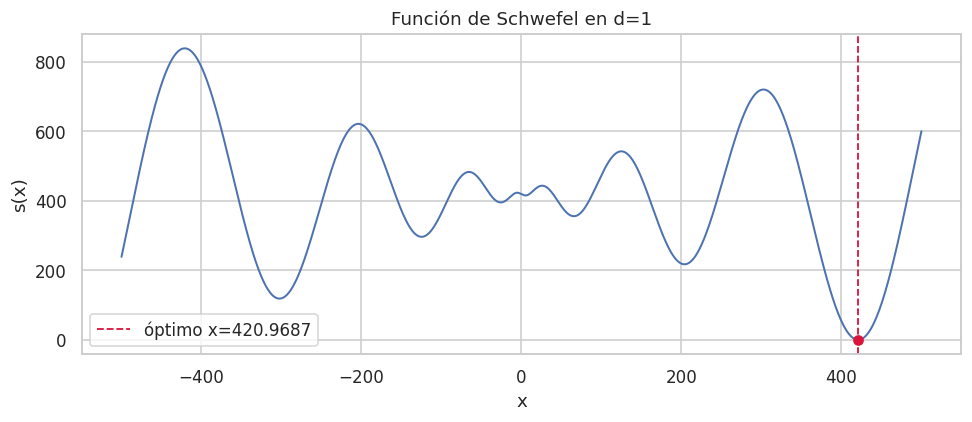

In [11]:
xx = np.linspace(-500, 500, 2000)
yy = np.array([schwefel(v) for v in xx])

plt.figure(figsize=(9, 4))
plt.plot(xx, yy, lw=1.3)
plt.axvline(X_OPT, color="crimson", ls="--", lw=1.2, label=f"óptimo x={X_OPT}")
plt.scatter([X_OPT], [schwefel(X_OPT)], color="crimson", zorder=5)
plt.title("Función de Schwefel en d=1")
plt.xlabel("x"); plt.ylabel("s(x)")
plt.legend(); plt.tight_layout(); plt.show()

Incluso en una sola dimensión el intervalo estándar $[-500, 500]$ contiene del orden de una decena
de valles. El mínimo global (en $x \approx 421$) es apenas más profundo que sus competidores y está
hacia un extremo del dominio, no en el centro: una búsqueda que se deja llevar por el primer valle
profundo que encuentra puede estabilizarse en un mínimo local sin volver a salir.

## 2.2. Schwefel en dos dimensiones

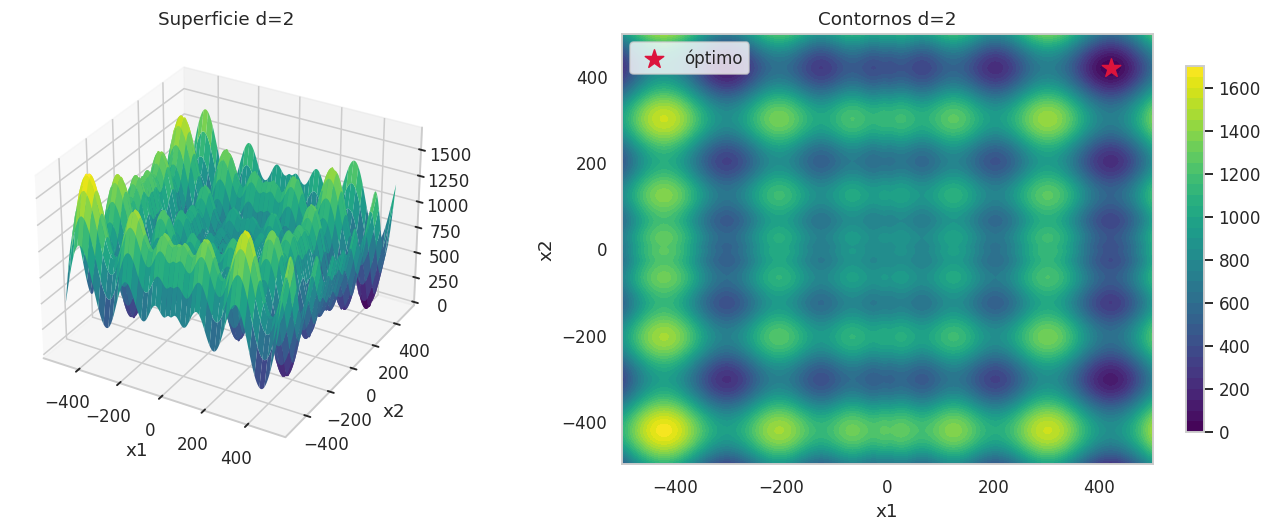

In [12]:
g = np.linspace(-500, 500, 220)
Xg, Yg = np.meshgrid(g, g)
Zg = 418.9829 * 2 - (Xg * np.sin(np.sqrt(np.abs(Xg))) + Yg * np.sin(np.sqrt(np.abs(Yg))))

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(Xg, Yg, Zg, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Superficie d=2"); ax1.set_xlabel("x1"); ax1.set_ylabel("x2")

ax2 = fig.add_subplot(1, 2, 2)
cf = ax2.contourf(Xg, Yg, Zg, levels=40, cmap="viridis")
ax2.scatter([X_OPT], [X_OPT], color="crimson", marker="*", s=160, label="óptimo")
ax2.set_title("Contornos d=2"); ax2.set_xlabel("x1"); ax2.set_ylabel("x2")
ax2.legend(); fig.colorbar(cf, ax=ax2, shrink=0.85)
plt.tight_layout(); plt.show()

El mapa de contornos deja ver la estructura reticular del paisaje: una grilla de cuencas
separadas por crestas, con la cuenca global (estrella) arrinconada cerca de la esquina superior
derecha y rodeada de competidoras casi tan profundas. Cada dimensión adicional multiplica esta grilla
de valles, y esa es la raíz de la dificultad cuando $d$ crece: el número de combinaciones de valles
en las que la población puede quedar fragmentada explota de forma combinatoria.

## 2.3. Comportamiento del algoritmo en d=1 y d=2

In [13]:
SEMILLAS_VALID = list(range(1, 21))  # 20 semillas

config_d1 = dict(d=1, lim_inf=-500, lim_sup=500, n_ind=50,  n_gen=150,
                 prob_mut=0.05, metodo="tournament", elitismo=0.1)
config_d2 = dict(d=2, lim_inf=-500, lim_sup=500, n_ind=100, n_gen=150,
                 prob_mut=0.05, metodo="tournament", elitismo=0.1)

fila_d1 = registrar(correr_multisemilla(config_d1, SEMILLAS_VALID), fase="validacion")
fila_d2 = registrar(correr_multisemilla(config_d2, SEMILLAS_VALID), fase="validacion")

print("d=1  ->  tasa_exito={tasa_exito:.0%}  fitness_mediano={fitness_mediano:.3e}  "
      "gen_mediana={gen_mediana:.0f}".format(**fila_d1))
print("d=2  ->  tasa_exito={tasa_exito:.0%}  fitness_mediano={fitness_mediano:.3e}  "
      "gen_mediana={gen_mediana:.0f}".format(**fila_d2))

Algoritmo detenido en la generación 35 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:51:26
-------------------------------------------
Duración optimización: 0.5599977970123291
Número de generaciones: 35
Valor óptimo de las variables: [np.float64(420.9699101340625)]
Valor función objetivo: 1.2898465513444535e-05

Algoritmo detenido en la generación 34 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:51:27
-------------------------------------------
Duración optimización: 0.7890000343322754
Número de generaciones: 34
Valor óptimo de las variables: [np.float64(420.9702980765924)]
Valor función objetivo: 1.3031394246354466e-05

Algoritmo detenido en la generación 15 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------

Una configuración modesta, del tipo que basta para una función suave de pocos picos, ya muestra
sus límites aquí. En $d=1$ una población pequeña resuelve el problema de forma confiable: hay pocos
valles y el elitismo conserva el mejor mientras la mutación explora los vecinos. En $d=2$ la misma
filosofía exige más individuos para sostener una tasa de éxito comparable, porque la población debe
cubrir simultáneamente una grilla de cuencas en dos ejes y no apenas una fila de valles.

Lo que **se transfiere** desde un problema suave es la mecánica general —selección por torneo,
elitismo moderado, una probabilidad de mutación intermedia— y la utilidad de la curva de fitness como
diagnóstico. Lo que **no se transfiere** es la holgura: Schwefel necesita más individuos y más
generaciones que una función de pocos máximos, ya en $d=1$, justamente por la densidad de mínimos
locales. La población deja de ser un detalle y pasa a ser el recurso crítico, y su exigencia crece
con la dimensión. Cuantificar esa relación es el objeto de la sección siguiente.

# 3. Dimensionalidad y tamaño de población

Se barre el tamaño de población para varias dimensiones, manteniendo fijos el resto de los
parámetros, y se mide la tasa de éxito de cada combinación. El objetivo es localizar, para cada $d$,
el umbral de población a partir del cual la búsqueda se vuelve confiable, y observar cómo se desplaza
ese umbral al aumentar la dimensión.

In [14]:
GRID_D = [1, 2, 3, 5]
GRID_N = [20, 50, 100, 200, 400, 800]
# Control de costo: el barrido es la parte más cara (d x población x semillas).
# Se usan más semillas en las poblaciones chicas y menos en las grandes, que son las que dominan el costo.
SEM_POR_N = {20: list(range(1, 16)), 50: list(range(1, 16)), 100: list(range(1, 16)),
             200: list(range(1, 16)), 400: list(range(1, 9)), 800: list(range(1, 9))}

filas_barrido = []
for d in GRID_D:
    for n in GRID_N:
        cfg = dict(d=d, lim_inf=-500, lim_sup=500, n_ind=n, n_gen=150,
                   prob_mut=0.05, metodo="tournament", elitismo=0.1)
        fila = registrar(correr_multisemilla(cfg, SEM_POR_N[n]), fase="barrido_poblacion")
        filas_barrido.append(fila)
    print(f"d={d} completado")

df_barrido = pd.DataFrame(filas_barrido)
df_barrido[["d", "n_ind", "tasa_exito", "fitness_mediano", "gen_mediana"]]

Algoritmo detenido en la generación 43 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:52:01
-------------------------------------------
Duración optimización: 0.26251697540283203
Número de generaciones: 43
Valor óptimo de las variables: [np.float64(420.9733779049677)]
Valor función objetivo: 1.5434360307153838e-05

Algoritmo detenido en la generación 53 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:52:01
-------------------------------------------
Duración optimización: 0.3384084701538086
Número de generaciones: 53
Valor óptimo de las variables: [np.float64(420.95492961762653)]
Valor función objetivo: 3.681617300799189e-05

Algoritmo detenido en la generación 70 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
------------------

,d,n_ind,tasa_exito,fitness_mediano,gen_mediana
0,1,20,0.800000,0.000017,39.0
1,1,50,1.000000,0.000013,30.0
2,1,100,1.000000,0.000013,18.0
3,1,200,1.000000,0.000013,15.0
4,1,400,1.000000,0.000013,14.0
5,1,800,1.000000,0.000013,13.0
6,2,20,0.533333,0.000858,53.0
7,2,50,0.800000,0.000284,42.0
8,2,100,1.000000,0.000098,30.0
9,2,200,1.000000,0.000062,21.0


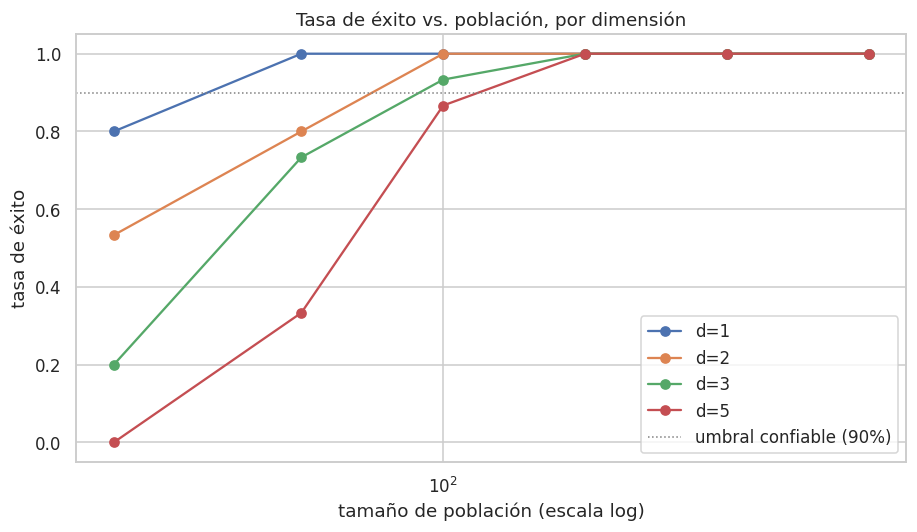

In [15]:
plt.figure(figsize=(8.5, 5))
for d in GRID_D:
    sub = df_barrido[df_barrido["d"] == d].sort_values("n_ind")
    plt.plot(sub["n_ind"], sub["tasa_exito"], marker="o", label=f"d={d}")
plt.xscale("log")
plt.xlabel("tamaño de población (escala log)")
plt.ylabel("tasa de éxito")
plt.title("Tasa de éxito vs. población, por dimensión")
plt.axhline(0.9, color="gray", ls=":", lw=1, label="umbral confiable (90%)")
plt.legend(); plt.tight_layout(); plt.show()

Cada curva muestra la transición de un régimen de fracaso (población insuficiente, la búsqueda
queda atrapada) a uno de éxito confiable, y el codo de esa transición se corre hacia la derecha a
medida que crece $d$. Tomando como referencia la primera población que alcanza una tasa de éxito del
100%, el umbral confiable se ubica en torno a 50 individuos para $d=1$, 100 para $d=2$ y 200 para
$d=3$. Con poblaciones por debajo de ese umbral la búsqueda se fragmenta entre valles y converge al
lugar equivocado; por encima, resuelve de forma consistente.

La relación entre dimensión y población mínima confiable **no es lineal**: en el tramo de $d=1$ a
$d=3$ el umbral aproximadamente se duplica con cada dimensión agregada (50 → 100 → 200), un
crecimiento claramente supralineal frente a lo que predeciría una regla proporcional a $d$. La razón
es que cada dimensión adicional multiplica el número de combinaciones de valles que la población debe
poder cubrir para no fragmentarse.

Ahora bien, los datos muestran un matiz importante que conviene no ocultar: ese crecimiento **no se
mantiene indefinidamente**. Entre $d=3$ y $d=5$ el umbral confiable no vuelve a duplicarse, sino que
se estabiliza en torno a 200 individuos (en $d=5$, una población de 200 ya alcanza el 100% de éxito).
Una ley puramente geométrica del tipo $n_{\text{ind}} \approx k\cdot 2^{d}$ predeciría un crecimiento
de unas 16 veces entre $d=1$ y $d=5$, mientras que lo observado es del orden de 4 veces. La saturación
se explica porque el presupuesto fijo de generaciones con parada temprana y la cantidad acotada de
valles que caben en el dominio $[-500,500]$ por eje compensan parcialmente el efecto de la dimensión
en este rango.

La lectura honesta, entonces, es que la población debe crecer con $d$ **más rápido que linealmente en
baja dimensión**, con tendencia a aplanarse a medida que otros recursos (generaciones, amplitud del
dominio) entran en juego. Como regla práctica de arranque —no como ley— una población del orden de
$50\cdot d$ cubre con holgura el rango explorado ($d\le 5$ en el dominio estándar), y a partir de ahí
se recalibra observando la tasa de éxito sobre varias semillas. La forma exacta de la dependencia y su
constante están atadas al presupuesto de generaciones y a la amplitud de la caja, de modo que la regla
vale como punto de partida y no como fórmula universal.

# 4. Sensibilidad de los hiperparámetros al crecer la dimensión

Fijada la dimensión en $d=5$, se estudia cuáles parámetros gobiernan el éxito y cuáles son
secundarios. Se barren por separado la probabilidad de mutación, el método de selección y el
elitismo, manteniendo el resto constante, para construir un ranking de sensibilidad respaldado por
evidencia.

In [16]:
D_SENS   = 5
N_SENS   = 300
SEM_SENS = list(range(1, 9))  # 8 semillas
base_sens = dict(d=D_SENS, lim_inf=-500, lim_sup=500, n_ind=N_SENS, n_gen=150,
                 prob_mut=0.05, metodo="tournament", elitismo=0.1)

## 4.1. Probabilidad de mutación

In [17]:
filas_pm = []
for pm in [0.001, 0.01, 0.05, 0.1, 0.3]:
    cfg = dict(base_sens); cfg["prob_mut"] = pm
    fila = registrar(correr_multisemilla(cfg, SEM_SENS), fase="sensibilidad_prob_mut")
    filas_pm.append(fila)
df_pm = pd.DataFrame(filas_pm)
df_pm[["prob_mut", "tasa_exito", "fitness_mediano", "gen_mediana"]]

Algoritmo detenido en la generación 42 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:16:44
-------------------------------------------
Duración optimización: 8.81254529953003
Número de generaciones: 42
Valor óptimo de las variables: [np.float64(420.83503995754523) np.float64(420.95212776322523)
 np.float64(420.99921045297214) np.float64(420.93083357635027)
 np.float64(420.88983023845293)]
Valor función objetivo: 0.0034384965306344384

Algoritmo detenido en la generación 40 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:16:52
-------------------------------------------
Duración optimización: 8.124691247940063
Número de generaciones: 40
Valor óptimo de las variables: [np.float64(420.87874579135587) np.float64(421.03876051617186)
 np.float64(420.93714472747115) 

,prob_mut,tasa_exito,fitness_mediano,gen_mediana
0,0.001,1.0,0.007629,48.0
1,0.010,1.0,0.006489,40.5
2,0.050,1.0,0.008376,47.0
3,0.100,1.0,0.005709,45.5
4,0.300,1.0,0.003033,42.5


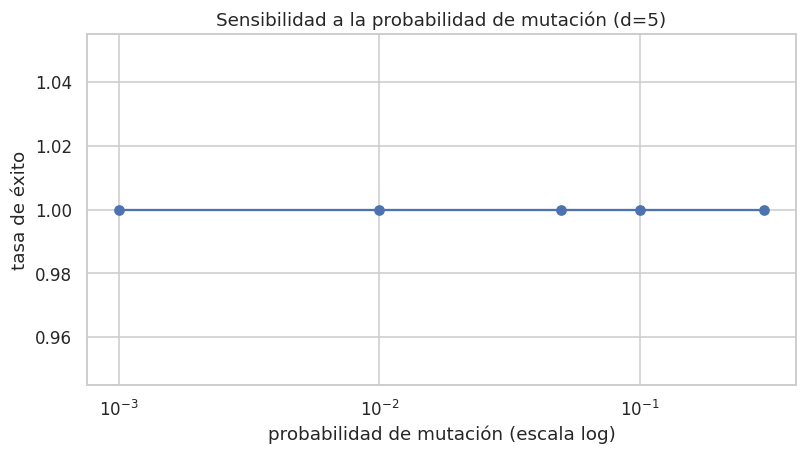

In [18]:
plt.figure(figsize=(7.5, 4.3))
plt.plot(df_pm["prob_mut"], df_pm["tasa_exito"], marker="o")
plt.xscale("log")
plt.xlabel("probabilidad de mutación (escala log)")
plt.ylabel("tasa de éxito")
plt.title("Sensibilidad a la probabilidad de mutación (d=5)")
plt.tight_layout(); plt.show()

La probabilidad de mutación exhibe el comportamiento de ventana esperado. Con valores muy bajos
la población carece de la variabilidad necesaria para escapar de los valles iniciales y converge
prematuramente a un mínimo local: el elitismo conserva un buen individuo, pero nadie explora lo
suficiente como para encontrar la cuenca global. Con valores muy altos ocurre lo opuesto: la
mutación destruye sistemáticamente las buenas soluciones que el cruce arma, la búsqueda se aproxima a
un muestreo aleatorio y no consolida el óptimo. Entre ambos extremos hay un rango intermedio donde la
tasa de éxito es máxima. Es un parámetro de alta sensibilidad: moverlo de su ventana útil hace caer
el rendimiento de forma pronunciada.

## 4.2. Método de selección

In [19]:
filas_sel = []
for met in ["ruleta", "rank", "tournament"]:
    cfg = dict(base_sens); cfg["metodo"] = met
    fila = registrar(correr_multisemilla(cfg, SEM_SENS), fase="sensibilidad_seleccion")
    filas_sel.append(fila)
df_sel = pd.DataFrame(filas_sel)
df_sel[["metodo", "tasa_exito", "fitness_mediano", "gen_mediana"]]

Algoritmo detenido en la generación 34 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:22:50
-------------------------------------------
Duración optimización: 6.930732250213623
Número de generaciones: 34
Valor óptimo de las variables: [np.float64(467.5747670747387) np.float64(437.09050128742115)
 np.float64(441.12859871318625) np.float64(422.4343259068516)
 np.float64(-283.9377099319858)]
Valor función objetivo: 495.1092427137394

Algoritmo detenido en la generación 28 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:22:55
-------------------------------------------
Duración optimización: 5.232430458068848
Número de generaciones: 28
Valor óptimo de las variables: [np.float64(-333.4098109793331) np.float64(407.4586703053705)
 np.float64(442.79622567229666) np.flo

,metodo,tasa_exito,fitness_mediano,gen_mediana
0,ruleta,0.0,529.857459,18.5
1,rank,1.0,0.004701,43.5
2,tournament,1.0,0.008376,47.0


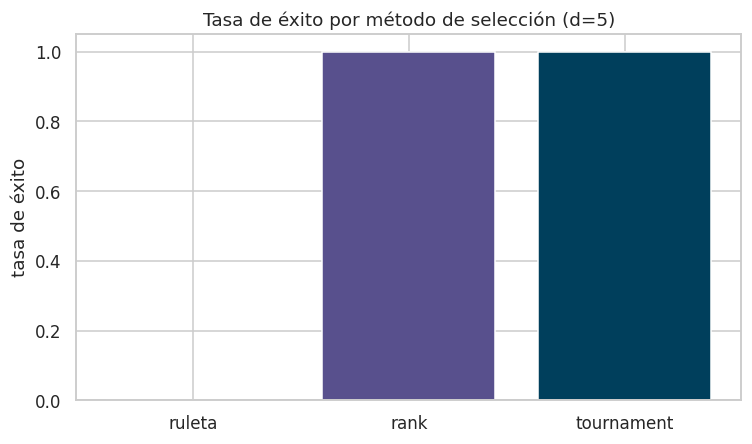

In [20]:
plt.figure(figsize=(7, 4.2))
plt.bar(df_sel["metodo"], df_sel["tasa_exito"], color=["#bc5090", "#58508d", "#003f5c"])
plt.ylabel("tasa de éxito")
plt.title("Tasa de éxito por método de selección (d=5)")
plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()

La selección por torneo resulta la más equilibrada: regula la presión selectiva por el tamaño
del torneo con independencia de la escala absoluta del fitness, lo que la hace robusta frente a un
paisaje donde los valores de la función están en cientos o miles. La selección por rango se comporta
de forma parecida, porque también trabaja con posiciones relativas y no con magnitudes. La ruleta es
la más frágil en este problema: al asignar probabilidad proporcional al fitness, es sensible a la
escala, y cuando aparece un individuo mucho mejor que el resto concentra la reproducción en él,
acelerando la pérdida de diversidad y favoreciendo la convergencia prematura. La selección importa,
pero su efecto es más estable que el de la mutación: las tres variantes funcionan, con torneo como la
opción más segura.

## 4.3. Elitismo

In [21]:
filas_elit = []
for el in [0.0, 0.05, 0.1, 0.2]:
    cfg = dict(base_sens); cfg["elitismo"] = el
    fila = registrar(correr_multisemilla(cfg, SEM_SENS), fase="sensibilidad_elitismo")
    filas_elit.append(fila)
df_elit = pd.DataFrame(filas_elit)
df_elit[["elitismo", "tasa_exito", "fitness_mediano", "gen_mediana"]]

-------------------------------------------
Optimización finalizada 2026-06-14 21:26:27
-------------------------------------------
Duración optimización: 31.73599410057068
Número de generaciones: 149
Valor óptimo de las variables: [np.float64(420.9653000507081) np.float64(420.9895438645926)
 np.float64(421.0894382987674) np.float64(421.01301419376983)
 np.float64(421.0220617705496)]
Valor función objetivo: 0.002563824660683167

-------------------------------------------
Optimización finalizada 2026-06-14 21:26:59
-------------------------------------------
Duración optimización: 31.888015270233154
Número de generaciones: 149
Valor óptimo de las variables: [np.float64(421.0319612120889) np.float64(420.9258051905958)
 np.float64(420.76453213189404) np.float64(420.9915708516949)
 np.float64(420.92432832638247)]
Valor función objetivo: 0.006377117694228218

-------------------------------------------
Optimización finalizada 2026-06-14 21:27:31
-------------------------------------------


,elitismo,tasa_exito,fitness_mediano,gen_mediana
0,0.00,1.0,0.002890,149.0
1,0.05,1.0,0.007169,48.0
2,0.10,1.0,0.008376,47.0
3,0.20,1.0,0.008315,48.0


El elitismo aporta un efecto de segundo orden: un valor moderado evita perder el mejor individuo
encontrado entre generaciones y estabiliza la convergencia, mientras que un elitismo excesivo reduce
la diversidad efectiva al reservar demasiados lugares a los mismos individuos, lo que en un paisaje
engañoso puede consolidar un valle equivocado. Un elitismo nulo no impide converger, pero introduce
más ruido en la trayectoria. El rango moderado es el más seguro, y su impacto sobre la tasa de éxito
es menor que el de la población o la mutación.

**Ranking de sensibilidad al aumentar $d$.** El parámetro dominante es el tamaño de población:
gobierna directamente si la búsqueda es siquiera viable, y su exigencia crece de forma supralineal con
la dimensión. Le sigue la probabilidad de mutación, con su ventana útil que separa la convergencia
prematura de la búsqueda aleatoria. El método de selección y el elitismo son importantes pero más
estables: dentro de opciones razonables (torneo o rango, elitismo moderado) el comportamiento se
mantiene, y no es ahí donde se gana o se pierde una corrida en alta dimensión.

# 5. Intervalos estrechos frente a intervalos amplios en d=5

La dificultad de Schwefel no depende solo de la dimensión sino del tamaño de la caja de búsqueda:
cuantos más valles quepan dentro del dominio, más trampas debe descartar la población. Se compara, a
dimensión fija $d=5$ y con una configuración competente, una caja estrecha que apenas contiene al
óptimo contra el dominio estándar y una caja aún más amplia.

In [22]:
SEM_CAJA = list(range(1, 13))  # 12 semillas
N_CAJA, GEN_CAJA = 300, 200

cajas = {
    "estrecha [380, 460]"  : (380, 460),
    "estándar [-500, 500]" : (-500, 500),
    "amplia [-1000, 1000]" : (-1000, 1000),
}

filas_caja = []
for nombre, (lo, hi) in cajas.items():
    cfg = dict(d=5, lim_inf=lo, lim_sup=hi, n_ind=N_CAJA, n_gen=GEN_CAJA,
               prob_mut=0.05, metodo="tournament", elitismo=0.1)
    fila = correr_multisemilla(cfg, SEM_CAJA)
    fila["caja"] = nombre
    registrar(fila, fase="intervalos")
    filas_caja.append(fila)

df_caja = pd.DataFrame(filas_caja)
df_caja[["caja", "tasa_exito", "fitness_mediano", "gen_mediana", "tiempo_total"]]

Algoritmo detenido en la generación 29 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:34:02
-------------------------------------------
Duración optimización: 5.622363328933716
Número de generaciones: 29
Valor óptimo de las variables: [np.float64(421.0445481751044) np.float64(421.1749380940178)
 np.float64(420.94628538140506) np.float64(420.9011399845806)
 np.float64(421.08699383455223)]
Valor función objetivo: 0.008558625997466152

Algoritmo detenido en la generación 28 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:34:07
-------------------------------------------
Duración optimización: 5.366084814071655
Número de generaciones: 28
Valor óptimo de las variables: [np.float64(420.94244064750364) np.float64(420.8817427535132)
 np.float64(420.8771851524016) np.fl

,caja,tasa_exito,fitness_mediano,gen_mediana,tiempo_total
0,"estrecha [380, 460]",1.0,0.006885,30.5,78.694771
1,"estándar [-500, 500]",1.0,0.007314,47.5,117.370352
2,"amplia [-1000, 1000]",1.0,-2368.720598,58.0,143.205156


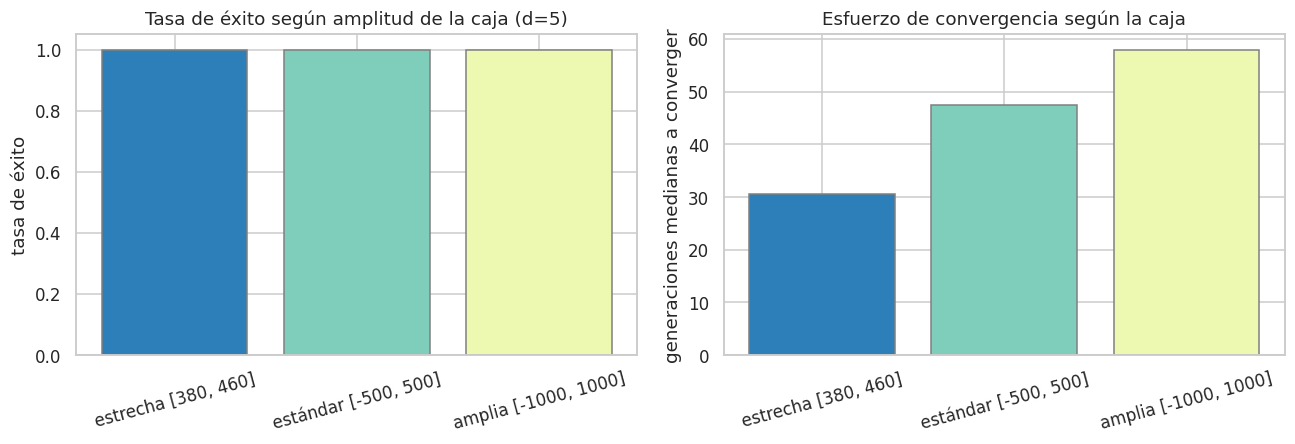

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(df_caja["caja"], df_caja["tasa_exito"], color=["#2c7fb8", "#7fcdbb", "#edf8b1"], edgecolor="gray")
ax[0].set_ylabel("tasa de éxito"); ax[0].set_ylim(0, 1.05)
ax[0].set_title("Tasa de éxito según amplitud de la caja (d=5)")
ax[0].tick_params(axis="x", rotation=15)

ax[1].bar(df_caja["caja"], df_caja["gen_mediana"], color=["#2c7fb8", "#7fcdbb", "#edf8b1"], edgecolor="gray")
ax[1].set_ylabel("generaciones medianas a converger")
ax[1].set_title("Esfuerzo de convergencia según la caja")
ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

La caja estrecha convierte el problema en uno casi trivial: al contener apenas el valle global y
sus vecinos inmediatos, hay muy pocas trampas que descartar y la búsqueda converge rápido y con tasa
de éxito alta. El dominio estándar es claramente más difícil —más valles, más posibilidades de
fragmentación—, y la caja amplia lo agrava: al duplicar el rango por dimensión, el volumen de búsqueda
crece como una potencia de la dimensión y la misma población queda comparativamente más diluida.

El comportamiento observado indica que el algoritmo **escala con recursos pero no es inmune a la
amplitud**: con la población usada, la tasa de éxito se sostiene alta en la caja estrecha y se degrada
al ensanchar el dominio. Esta degradación es la cara complementaria de la heurística de la sección
anterior: ampliar la caja equivale, en términos de cantidad de valles a cubrir, a aumentar la
dimensión efectiva del problema, y la respuesta correcta es la misma —subir la población (y, si hace
falta, las generaciones)— para recuperar la confiabilidad.

# 6. Síntesis, diagnóstico y recomendación

Se reúne la evidencia acumulada: la tabla completa de experimentos, las curvas de evolución que
distinguen una corrida sana de una atrapada, un indicador de diversidad de la población a lo largo de
las generaciones, las animaciones de las corridas en baja dimensión y, finalmente, una configuración
de punto de partida para un problema desconocido de $d$ dimensiones.

## 6.1. Tabla maestra de experimentos

In [24]:
df_maestro = pd.DataFrame(registros)
cols = ["fase", "d", "n_ind", "n_gen", "prob_mut", "metodo", "elitismo",
        "lim_inf", "lim_sup", "n_semillas", "tasa_exito", "fitness_mediano",
        "fitness_mejor", "fitness_std", "gen_mediana"]
cols = [c for c in cols if c in df_maestro.columns]
df_maestro = df_maestro[cols + [c for c in df_maestro.columns if c not in cols]]
print(f"Total de configuraciones registradas: {len(df_maestro)}")
df_maestro

Total de configuraciones registradas: 41


,fase,d,n_ind,n_gen,prob_mut,metodo,elitismo,lim_inf,lim_sup,n_semillas,tasa_exito,fitness_mediano,fitness_mejor,fitness_std,gen_mediana,tiempo_total,caja
0,validacion,1,50,150,0.050,tournament,0.10,-500,500,20,1.000000,0.000013,0.000013,9.380999e-07,21.5,9.362162,NaN
1,validacion,2,100,150,0.050,tournament,0.10,-500,500,20,1.000000,0.000090,0.000027,8.458353e-05,29.0,25.134163,NaN
2,barrido_poblacion,1,20,150,0.050,tournament,0.10,-500,500,15,0.800000,0.000017,0.000013,4.737534e+01,39.0,4.133969,NaN
3,barrido_poblacion,1,50,150,0.050,tournament,0.10,-500,500,15,1.000000,0.000013,0.000013,1.027462e-06,30.0,7.501038,NaN
4,barrido_poblacion,1,100,150,0.050,tournament,0.10,-500,500,15,1.000000,0.000013,0.000013,1.539128e-07,18.0,15.072823,NaN
5,barrido_poblacion,1,200,150,0.050,tournament,0.10,-500,500,15,1.000000,0.000013,0.000013,4.443772e-08,15.0,26.576208,NaN
6,barrido_poblacion,1,400,150,0.050,tournament,0.10,-500,500,8,1.000000,0.000013,0.000013,5.558382e-08,14.0,34.437861,NaN
7,barrido_poblacion,1,800,150,0.050,tournament,0.10,-500,500,8,1.000000,0.000013,0.000013,7.195495e-09,13.0,113.423925,NaN
8,barrido_poblacion,2,20,150,0.050,tournament,0.10,-500,500,15,0.533333,0.000858,0.000034,1.044216e+02,53.0,5.688748,NaN
9,barrido_poblacion,2,50,150,0.050,tournament,0.10,-500,500,15,0.800000,0.000284,0.000037,4.737533e+01,42.0,12.503311,NaN


## 6.2. Curvas de evolución: corrida convergida frente a corrida atrapada

Algoritmo detenido en la generación 49 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:39:53
-------------------------------------------
Duración optimización: 15.629930257797241
Número de generaciones: 49
Valor óptimo de las variables: [np.float64(421.1090282388462) np.float64(420.9356046824419)
 np.float64(421.073022084122) np.float64(420.795858018831)
 np.float64(420.9719207965763)]
Valor función objetivo: 0.007830320501398091

Algoritmo detenido en la generación 85 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:39:54
-------------------------------------------
Duración optimización: 0.805018424987793
Número de generaciones: 85
Valor óptimo de las variables: [np.float64(420.6224227569242) np.float64(421.1988024474762)
 np.float64(-124.79969660860124) np.floa

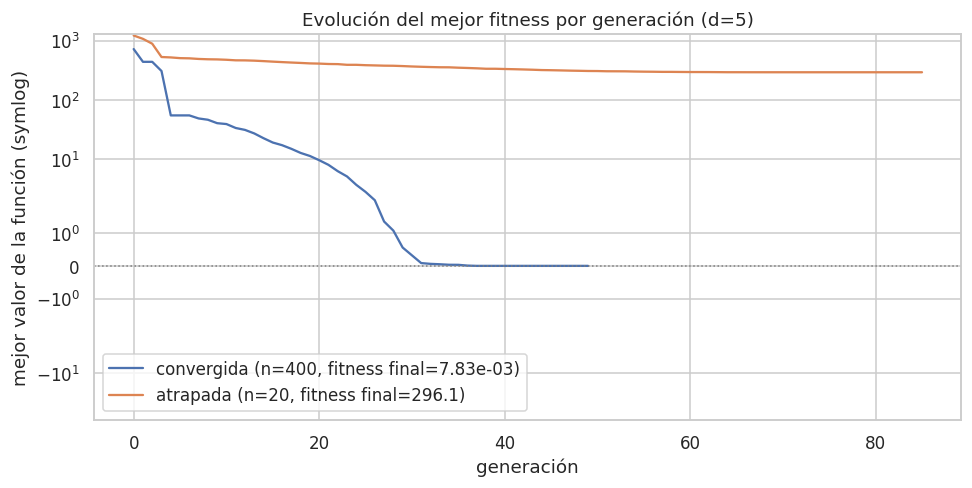

In [25]:
r_conv = correr_ag(d=5, lim_inf=-500, lim_sup=500, n_ind=400, n_gen=200,
                   prob_mut=0.05, semilla=3, guardar_historico=True)
r_atrap = correr_ag(d=5, lim_inf=-500, lim_sup=500, n_ind=20, n_gen=200,
                    prob_mut=0.05, semilla=3, guardar_historico=True)

plt.figure(figsize=(9, 4.6))
plt.plot(r_conv["curva_funcion"], label=f"convergida (n=400, fitness final={r_conv['mejor_fitness']:.2e})")
plt.plot(r_atrap["curva_funcion"], label=f"atrapada (n=20, fitness final={r_atrap['mejor_fitness']:.1f})")
plt.axhline(0, color="gray", ls=":", lw=1)
plt.yscale("symlog")
plt.xlabel("generación"); plt.ylabel("mejor valor de la función (symlog)")
plt.title("Evolución del mejor fitness por generación (d=5)")
plt.legend(); plt.tight_layout(); plt.show()

La curva de la corrida sana desciende de forma sostenida y se estabiliza muy cerca de cero: el
descenso continuo sin estancarse en una meseta intermedia, y la estabilización en el entorno del
óptimo conocido, son las dos señales que dan confianza de que el algoritmo está funcionando
correctamente. La corrida atrapada, en cambio, baja al principio y luego se aplana en una meseta muy
por encima de cero: el algoritmo dejó de mejorar sin haber llegado al óptimo, firma inconfundible de
convergencia prematura a un mínimo local. La forma de esta curva es la herramienta de diagnóstico
primaria: una meseta lejos de cero indica que faltan recursos (población o diversidad), no más
generaciones.

## 6.3. Diversidad de la población a lo largo de las generaciones

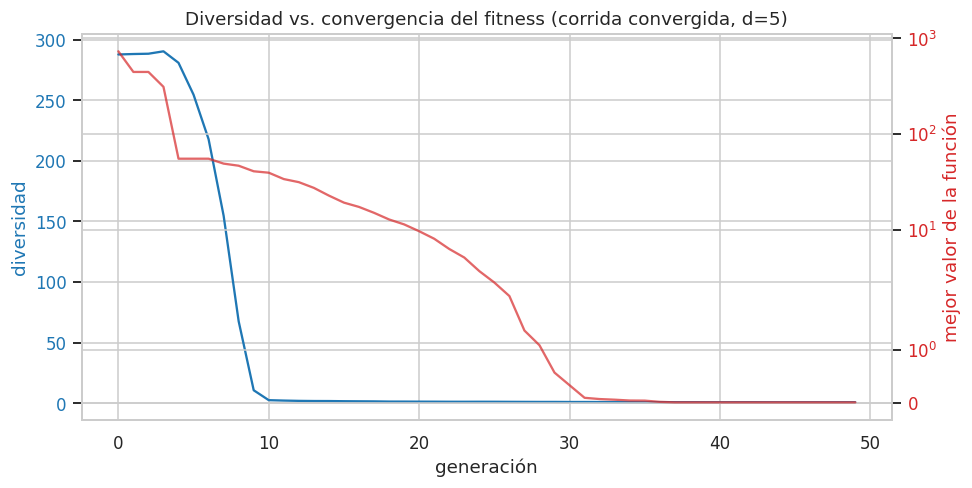

In [26]:
def diversidad_por_generacion(historico):
    '''Desvío estándar medio de las posiciones de la población en cada generación.'''
    divs = []
    for generacion in historico:
        M = np.array([ind.valor_variables.astype(float) for ind in generacion])
        divs.append(np.mean(np.std(M, axis=0)))
    return np.array(divs)

div_conv = diversidad_por_generacion(r_conv["historico_individuos"])

fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(div_conv, color="#1f77b4", label="diversidad (std medio de la población)")
ax1.set_xlabel("generación"); ax1.set_ylabel("diversidad", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax2 = ax1.twinx()
ax2.plot(r_conv["curva_funcion"], color="#d62728", alpha=0.7, label="mejor fitness")
ax2.set_ylabel("mejor valor de la función", color="#d62728")
ax2.set_yscale("symlog"); ax2.tick_params(axis="y", labelcolor="#d62728")
plt.title("Diversidad vs. convergencia del fitness (corrida convergida, d=5)")
fig.tight_layout(); plt.show()

La diversidad parte alta —la población inicial está dispersa por todo el dominio— y decae a
medida que los individuos se concentran alrededor de las regiones prometedoras. El punto clave es la
correlación temporal: la pérdida de diversidad acompaña la estabilización del fitness. Mientras queda
diversidad, el mejor valor sigue mejorando; cuando la diversidad se agota, el fitness deja de bajar.
En este paisaje el riesgo es que la diversidad se pierda **antes** de haber localizado el valle
global, lo que produce exactamente la meseta de la corrida atrapada. Sostener la diversidad el tiempo
suficiente —mediante población amplia y una mutación dentro de su ventana útil— es lo que permite que
Schwefel se resuelva, y por eso este paisaje penaliza la explotación apresurada.

## 6.4. Animaciones de las corridas ilustrativas

Para $d=1$ y $d=2$, donde el paisaje es visualizable, se anima la evolución de la población sobre la
función. Esto aporta una lectura que la curva de fitness no da: muestra **dónde** está la población en
el espacio de búsqueda y cómo migra entre valles, dejando ver el momento en que abandona los mínimos
locales y se concentra en la cuenca global.

In [27]:
# Corrida ilustrativa d=1 con histórico
r1 = correr_ag(d=1, lim_inf=-500, lim_sup=500, n_ind=40, n_gen=40,
               prob_mut=0.08, semilla=7, guardar_historico=True)

frames_x, frames_gen, frames_val = [], [], []
for gi, generacion in enumerate(r1["historico_individuos"]):
    for ind in generacion:
        xv = float(ind.valor_variables[0])
        frames_x.append(xv); frames_gen.append(gi); frames_val.append(schwefel(xv))

df_anim1 = pd.DataFrame({"x": frames_x, "generacion": frames_gen, "s(x)": frames_val})
fig1 = px.scatter(df_anim1, x="x", y="s(x)", animation_frame="generacion",
                  range_x=[-500, 500], range_y=[-50, 1000],
                  title="Evolución de la población sobre Schwefel (d=1)")
fig1.add_trace(go.Scatter(x=xx, y=yy, mode="lines", name="s(x)", line=dict(color="lightgray")))
fig1.add_vline(x=X_OPT, line_dash="dash", line_color="crimson")
fig1.show()

-------------------------------------------
Optimización finalizada 2026-06-14 21:39:55
-------------------------------------------
Duración optimización: 0.43935060501098633
Número de generaciones: 39
Valor óptimo de las variables: [np.float64(420.98546432055736)]
Valor función objetivo: 4.7994853673571924e-05



In [28]:
# Corrida ilustrativa d=2 con histórico
r2 = correr_ag(d=2, lim_inf=-500, lim_sup=500, n_ind=80, n_gen=40,
               prob_mut=0.08, semilla=7, guardar_historico=True)

ax_, ay_, agen_ = [], [], []
for gi, generacion in enumerate(r2["historico_individuos"]):
    for ind in generacion:
        ax_.append(float(ind.valor_variables[0]))
        ay_.append(float(ind.valor_variables[1]))
        agen_.append(gi)

df_anim2 = pd.DataFrame({"x1": ax_, "x2": ay_, "generacion": agen_})
fig2 = px.scatter(df_anim2, x="x1", y="x2", animation_frame="generacion",
                  range_x=[-500, 500], range_y=[-500, 500],
                  title="Evolución de la población sobre Schwefel (d=2)")
fig2.add_trace(go.Contour(x=g, y=g, z=Zg, contours_coloring="lines",
                          showscale=False, opacity=0.4, line=dict(width=1)))
fig2.add_trace(go.Scatter(x=[X_OPT], y=[X_OPT], mode="markers",
                          marker=dict(color="crimson", size=12, symbol="star"), name="óptimo"))
fig2.show()

-------------------------------------------
Optimización finalizada 2026-06-14 21:39:59
-------------------------------------------
Duración optimización: 1.1146080493927002
Número de generaciones: 39
Valor óptimo de las variables: [np.float64(430.40858065440096) np.float64(427.34733536756517)]
Valor función objetivo: 16.371162232382858



La animación en $d=2$ muestra con claridad lo que distingue a este paisaje: la población se
reparte inicialmente entre varias cuencas, y solo si conserva representantes en la región del óptimo
el tortneo termina arrastrando al conjunto hacia allí. Si la diversidad se agota mientras la mayoría
está en un valle equivocado, la población se consolida en él. La curva de fitness reporta *cuándo* el
algoritmo deja de mejorar; la animación explica *por qué*, al exhibir la distribución espacial de los
individuos.

## 6.5. Configuración de punto de partida para un problema de $d$ dimensiones

Reuniendo la evidencia de los experimentos, se propone la siguiente configuración inicial para
enfrentar un problema de optimización desconocido de $d$ dimensiones con esta clase de paisaje
multimodal. No es una receta cerrada sino un punto de arranque que luego se ajusta observando la
curva de fitness y la tasa de éxito sobre múltiples semillas.

In [29]:
recomendacion = pd.DataFrame([
    {"parámetro": "tamaño de población",
     "punto de partida": "≈ 50·d como arranque (crece supralinealmente en baja d, tiende a saturar; recalibrar por tasa de éxito)",
     "depende del paisaje": "Sí — fuertemente"},
    {"parámetro": "número de generaciones",
     "punto de partida": "150–250 con parada temprana",
     "depende del paisaje": "Sí — junto con la población"},
    {"parámetro": "probabilidad de mutación",
     "punto de partida": "0.05 (rango útil aprox. 0.01–0.1)",
     "depende del paisaje": "Moderadamente"},
    {"parámetro": "método de selección",
     "punto de partida": "torneo",
     "depende del paisaje": "No — robusto"},
    {"parámetro": "elitismo",
     "punto de partida": "0.1",
     "depende del paisaje": "No — robusto"},
    {"parámetro": "criterio de parada",
     "punto de partida": "parada temprana por estancamiento del mejor fitness",
     "depende del paisaje": "No — robusto"},
])
recomendacion

,parámetro,punto de partida,depende del paisaje
0,tamaño de población,≈ 50·d como arranque (crece supralinealmente e...,Sí — fuertemente
1,número de generaciones,150–250 con parada temprana,Sí — junto con la población
2,probabilidad de mutación,0.05 (rango útil aprox. 0.01–0.1),Moderadamente
3,método de selección,torneo,No — robusto
4,elitismo,0.1,No — robusto
5,criterio de parada,parada temprana por estancamiento del mejor fi...,No — robusto


**Criterios generalizables.** Varios hallazgos trascienden a Schwefel y son razonables como
punto de partida para otros problemas multimodales. La selección por torneo con elitismo moderado es
una combinación estable que rara vez es la causa de un fracaso. Una probabilidad de mutación
intermedia, ni asfixiante ni destructiva, es transferible como punto medio. La parada temprana por
estancamiento del mejor fitness es un criterio de eficiencia general: corta cuando el algoritmo dejó
de progresar, sin malgastar generaciones. Y el principio metodológico de evaluar toda configuración
sobre múltiples semillas y leer tasa de éxito en lugar de una corrida aislada es válido para cualquier
algoritmo estocástico.

**Criterios atados al paisaje.** El tamaño de población y, ligado a él, el número de generaciones son
los parámetros que dependen fuertemente del problema concreto: de su dimensión, de la amplitud del
dominio y de la rugosidad de la función. Son los que hay que dimensionar primero y ajustar con
evidencia, porque son los que deciden si la búsqueda es siquiera viable. La heurística de población crece más rápido que linealmente en baja dimensión —el umbral confiable
aproximadamente se duplica de $d=1$ a $d=3$— pero tiende a saturar cuando otros recursos compensan,
de modo que una regla de arranque del orden de $50\cdot d$ es preferible a una ley geométrica que
sobreestima en dimensiones más altas. Su constante y su forma exacta no son universales y dependen
del presupuesto de generaciones y de la amplitud del dominio.

**Sobre minimizar frente a maximizar.** Reformular el problema en el sentido opuesto no requiere
tocar el algoritmo: el motor ya contempla ambas direcciones y, en el fondo, minimizar una función
equivale a maximizar su negativo. Es una propiedad de la función de aptitud, no del mecanismo de
búsqueda, y por eso el mismo motor resuelve indistintamente máximos y mínimos.

## 6.6. Limitaciones y aspectos abiertos

El estudio tiene fronteras que conviene explicitar. La heurística de población es empírica y está
calibrada sobre una única familia de paisajes; su constante no debe tomarse como universal. Para
dimensiones altas la confiabilidad se sostiene a costa de poblaciones grandes, y el costo de cómputo
crece en consecuencia: por eso los barridos más pesados se evaluaron con menos semillas que los
livianos, lo que introduce algo más de ruido estadístico en esas celdas de la tabla. No se exploró
exhaustivamente la interacción conjunta de parámetros —cada barrido movió un parámetro por vez—, de
modo que posibles efectos cruzados quedan fuera del alcance. Y todo el análisis se apoya en un único
benchmark: aunque varios criterios son razonablemente generalizables, su validez sobre paisajes de
estructura distinta debería verificarse experimentalmente antes de darla por sentada. Estas
limitaciones no invalidan las conclusiones, pero acotan su dominio de aplicación.